In [ ]:
import pandas as pd
import numpy as np
d = pd.read_csv("/content/pmindia.v1.te-en.tsv", sep='\t')
print(d)

      The Union Cabinet chaired by Prime Minister Shri Narendra Modi has approved the proposal for closure of Autonomous Bodies, namely, Rashtriya Arogya Nidhi (RAN) and Jansankhya Sthirata Kosh (JSK) and the functions are proposed to be vested in Department of Health & Family Welfare (DoHFW).  \
0      The rationalization of Autonomous Bodies under...                                                                                                                                                                                                                                                 
1      An advance is placed with the Medical Superint...                                                                                                                                                                                                                                                 
2      Since the DoHFW provides funds to the hospital...                                                  

In [ ]:
%pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=50d69911e326a6207697ae7a0fd6d1f317bfa4ff46dc60c3fb41e0902c672406
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [ ]:
!pip install rouge --quiet

In [ ]:
!pip uninstall numpy -y
!pip uninstall pandas -y
!pip uninstall scikit-learn -y

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1


In [ ]:
!pip install numpy==1.23.5
!pip install pandas
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 49.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 69.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 110.7 MB/s eta 0:00:00


with k-fold

In [ ]:
"""
Phono-Semantic Hybrid Intelligence Framework for Telugu Neural Translation
==========================================================================
Architecture : MBart-50 + Transliteration-Aware Embedding + Phono-Semantic Units
               + Cross-Attention Phoneme Layer + Semantic Copy Mechanism
               + Ensemble Decoding (Beam + Nucleus)
Dataset      : obj 1 dataset.xlsx  (Excel with Telugu | English columns)
Evaluation   : BLEU · ROUGE(P/R/F) · ChrF++ · TER · COMET · K-Fold CV
               · Statistical Analysis · Ablation · 11 Plots

BUGFIX v4:
  FIX-10 RuntimeError tensor size mismatch: The encoder output passed to
         self.mbart() was conflicting with the attention_mask because MBart's
         forward() re-validates sequence lengths. Fixed by using
         BaseModelOutput wrapper and skipping the double-encode path entirely.
         Also fixed copy_gate shape broadcasting bug.
"""

# ══════════════════════════════════════════════════════════════════════════════
# 0.  INSTALL + RESTART
# ══════════════════════════════════════════════════════════════════════════════
import subprocess, sys, os

def _pip(*pkgs, flags=None):
    cmd = [sys.executable, "-m", "pip", "install", "-q",
           "--break-system-packages", *(flags or []), *pkgs]
    subprocess.check_call(cmd)

def _pip_uninstall(*pkgs):
    subprocess.check_call(
        [sys.executable, "-m", "pip", "uninstall", "-y", "--break-system-packages",
         *pkgs],
        stderr=subprocess.DEVNULL,
    )

_NUMPY_REINSTALLED_FLAG = os.path.join(
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in dir() else "/tmp",
    ".numpy_abi_fixed"
)

if not os.path.exists(_NUMPY_REINSTALLED_FLAG):
    print("[FIX-9] Reinstalling numpy to fix ABI mismatch …")
    _pip_uninstall("numpy")
    _pip("numpy>=1.26.0,<2.0.0", flags=["--no-cache-dir"])
    open(_NUMPY_REINSTALLED_FLAG, "w").close()
    print("[FIX-9] numpy reinstalled. Restarting Python process …")
    os.execv(sys.executable, [sys.executable] + sys.argv)

_pip(
    "transformers>=4.40.0",
    "sentencepiece",
    "sacrebleu>=2.3.1",
    "rouge-score",
    "torch",
    "pandas",
    "openpyxl",
    "matplotlib",
    "seaborn",
    "scipy",
    "scikit-learn",
    "tqdm",
    "unbabel-comet>=2.2.0",
    "accelerate>=0.26.0",
)

# ══════════════════════════════════════════════════════════════════════════════
# 1.  IMPORTS
# ══════════════════════════════════════════════════════════════════════════════
import re, gc, json, warnings, time, random
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    MBartForConditionalGeneration,
    MBart50TokenizerFast,
    get_linear_schedule_with_warmup,
)
from transformers.modeling_outputs import BaseModelOutput  # FIX-10: needed for encoder wrapper
from sacrebleu.metrics import BLEU, CHRF, TER
from rouge_score import rouge_scorer
from sklearn.model_selection import KFold
from scipy import stats
from tqdm import tqdm

try:
    from comet import download_model, load_from_checkpoint as comet_load
    _COMET_AVAILABLE = True
except ImportError:
    _COMET_AVAILABLE = False
    print("[WARN] unbabel-comet not importable — COMET will be skipped.")

warnings.filterwarnings("ignore")
torch.manual_seed(42); np.random.seed(42); random.seed(42)

# ══════════════════════════════════════════════════════════════════════════════
# 2.  CONFIG
# ══════════════════════════════════════════════════════════════════════════════
CFG = {
    "data_path"                  : "/kaggle/input/datasets/saibunny22/pm-india-11/pmindia.v1.te-en.tsv",
    "output_dir"                 : "./phono_semantic_outputs",
    "plots_dir"                  : "./phono_semantic_outputs/plots",
    "model_name"                 : "facebook/mbart-large-50-many-to-many-mmt",
    "src_lang"                   : "en_XX",
    "tgt_lang"                   : "te_IN",
    "max_samples"                : 40000,
    "max_input_length"           : 128,
    "max_target_length"          : 128,
    "train_batch_size"           : 4,
    "eval_batch_size"            : 8,
    "num_epochs"                 : 3,
    "learning_rate"              : 2e-5,
    "warmup_ratio"               : 0.1,
    "weight_decay"               : 0.01,
    "gradient_accumulation_steps": 8,
    "fp16"                       : torch.cuda.is_available(),
    "k_folds"                    : 5,
    "phonosem_dim"               : 256,
    "dropout"                    : 0.1,
    "label_smoothing"            : 0.1,
    "curriculum_epochs"          : 3,
    "bt_loss_weight"             : 0.2,
    "num_beams"                  : 6,
    "ensemble_nucleus_p"         : 0.92,
    "gradient_checkpointing"     : True,
    "ablation_variants"          : [
        "full_model",
        "no_phonosem",
        "no_transliteration_tag",
        "no_hybrid_embed",
        "no_copy_gate",
    ],
    "comet_model"                : "Unbabel/wmt22-comet-da",
}

def _find_data() -> str:
    if os.path.isfile(CFG["data_path"]):
        return CFG["data_path"]
    for root, _, files in os.walk("/content"):
        for fname in files:
            if fname.endswith((".xlsx", ".xls")):
                p = os.path.join(root, fname)
                print(f"[DATA] Found Excel: {p}"); return p
    for root, _, files in os.walk("/kaggle/input"):
        for fname in files:
            if "te-en" in fname and fname.endswith(".tsv"):
                p = os.path.join(root, fname)
                print(f"[DATA] Found TSV: {p}"); return p
    raise FileNotFoundError("Dataset not found. Upload 'obj 1 dataset.xlsx' to /content/")

CFG["data_path"] = _find_data()
os.makedirs(CFG["output_dir"], exist_ok=True)
os.makedirs(CFG["plots_dir"],  exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device: {DEVICE}  |  Data: {CFG['data_path']}")
if torch.cuda.is_available():
    print(f"[INFO] GPU: {torch.cuda.get_device_name(0)}  "
          f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ══════════════════════════════════════════════════════════════════════════════
# 3.  TOKENIZER
# ══════════════════════════════════════════════════════════════════════════════
def build_tokenizer(cfg) -> MBart50TokenizerFast:
    tok = MBart50TokenizerFast.from_pretrained(cfg["model_name"])
    tok.src_lang = cfg["src_lang"]
    existing = list(tok.special_tokens_map.get("additional_special_tokens", []))
    for sp in ["<TRANSLIT>", "<COPY>"]:
        if sp not in tok.all_special_tokens:
            existing.append(sp)
    tok.add_special_tokens({"additional_special_tokens": existing})
    return tok

def encode_src(tokenizer, texts, cfg):
    tokenizer.src_lang = cfg["src_lang"]
    return tokenizer(texts, max_length=cfg["max_input_length"],
                     truncation=True, padding=True, return_tensors="pt")

def encode_tgt(tokenizer, texts, cfg):
    tokenizer.src_lang = cfg["tgt_lang"]
    enc = tokenizer(texts, max_length=cfg["max_target_length"],
                    truncation=True, padding=True, return_tensors="pt")
    tokenizer.src_lang = cfg["src_lang"]
    return enc

# ══════════════════════════════════════════════════════════════════════════════
# 4.  TRANSLITERATION UTILITIES
# ══════════════════════════════════════════════════════════════════════════════
TELUGU_PHONEME_MAP = {
    "ka":"క","kha":"ఖ","ga":"గ","gha":"ఘ","na":"న","cha":"చ","ja":"జ",
    "ta":"త","tha":"థ","da":"ద","dha":"ధ","pa":"ప","pha":"ఫ","ba":"బ",
    "bha":"భ","ma":"మ","ya":"య","ra":"ర","la":"ల","va":"వ","sha":"శ",
    "sa":"స","ha":"హ","a":"అ","aa":"ఆ","i":"ఇ","ii":"ఈ","u":"ఉ",
    "uu":"ఊ","e":"ఎ","ee":"ఏ","o":"ఒ","oo":"ఓ",
    "hospital":"హాస్పిటల్","school":"స్కూల్","police":"పోలీస్",
    "minister":"మంత్రి","india":"ఇండియా","delhi":"ఢిల్లీ",
    "mumbai":"ముంబై","cricket":"క్రికెట్","computer":"కంప్యూటర్",
    "internet":"ఇంటర్నెట్","mobile":"మొబైల్","covid":"కోవిడ్",
    "vaccine":"వ్యాక్సిన్",
}
NE_PAT     = re.compile(r'\b([A-Z][a-z]+(?:\s[A-Z][a-z]+)*|[A-Z]{2,})\b')
TECH_TERMS = {
    "AI","ML","NLP","API","GDP","BJP","INC","PM","CM","UN","WHO",
    "NASA","ISRO","RBI","SEBI","UPI","GST","IT","ICU","OPD","COVID",
}

def is_transliterable(token: str) -> bool:
    t = token.strip()
    if not t:                            return False
    if t.upper() in TECH_TERMS:         return True
    if len(t) > 1 and t[0].isupper():   return True
    if any(c.isdigit() for c in t):     return True
    if t.lower() in TELUGU_PHONEME_MAP:  return True
    return False

def phonetic_tag_sentence(sentence: str) -> str:
    tokens, out = sentence.split(), []
    for tok in tokens:
        clean = re.sub(r'[^\w]', '', tok)
        out.append(f"<TRANSLIT> {tok}" if is_transliterable(clean) else tok)
    return " ".join(out)

def build_phonosem_features(sentence: str, dim: int = 256) -> np.ndarray:
    tokens = sentence.split()
    n  = max(len(tokens), 1)
    tf  = sum(is_transliterable(t) for t in tokens) / n
    nef = len(NE_PAT.findall(sentence)) / n

    vec = np.zeros(dim, dtype=np.float32)
    for tok in tokens:
        for i in range(len(tok) - 1):
            vec[hash(tok[i:i+2]) % dim] += 1.0
    for tok in tokens:
        for i in range(len(tok) - 2):
            vec[hash(tok[i:i+3]) % (dim // 2)] += 0.5

    if vec.sum() > 0:
        vec /= vec.sum()
    vec[0], vec[1] = tf, nef
    vec[2] = min(len(tokens) / 30.0, 1.0)
    vec[3] = sum(1 for t in tokens if not t.isascii()) / n
    return vec

# ══════════════════════════════════════════════════════════════════════════════
# 5.  DATASET
# ══════════════════════════════════════════════════════════════════════════════
def load_pmindia(path: str, max_samples: int) -> Tuple[List[str], List[str]]:
    en_sents, te_sents = [], []
    print(f"[DATA] Loading {path} …")
    if path.endswith((".xlsx", ".xls")):
        df = pd.read_excel(path)
        df.columns = [c.strip() for c in df.columns]
        if "Telugu" not in df.columns or "English" not in df.columns:
            raise ValueError(f"Expected 'Telugu' and 'English' columns, got: {list(df.columns)}")
        for _, row in df.iterrows():
            te = str(row["Telugu"]).strip()
            en = str(row["English"]).strip()
            if te in ("nan","") or en in ("nan",""):
                continue
            if len(en) < 3 or len(te) < 3:
                continue
            en_sents.append(en); te_sents.append(te)
            if len(en_sents) >= max_samples:
                break
    else:
        with open(path, encoding="utf-8") as fh:
            for line in fh:
                parts = line.strip().split("\t")
                if len(parts) < 2:
                    continue
                te, en = parts[0].strip(), parts[1].strip()
                if len(en) < 3 or len(te) < 3:
                    continue
                en_sents.append(en); te_sents.append(te)
                if len(en_sents) >= max_samples:
                    break
    print(f"[DATA] Loaded {len(en_sents):,} pairs.")
    return en_sents, te_sents

class PhonoSemanticDataset(Dataset):
    def __init__(self, en_sents, te_sents, cfg,
                 apply_tag=True, curriculum_sort=False):
        pairs = list(zip(en_sents, te_sents))
        if curriculum_sort:
            pairs.sort(key=lambda x: len(x[0].split()))
        self.en_sents  = [p[0] for p in pairs]
        self.te_sents  = [p[1] for p in pairs]
        self.cfg       = cfg
        self.apply_tag = apply_tag

    def __len__(self): return len(self.en_sents)

    def __getitem__(self, idx):
        src = self.en_sents[idx]
        return {
            "src"     : phonetic_tag_sentence(src) if self.apply_tag else src,
            "tgt"     : self.te_sents[idx],
            "phonosem": build_phonosem_features(src, self.cfg["phonosem_dim"]),
            "src_raw" : src,
        }

def make_collate(tokenizer, cfg):
    def collate(batch):
        srcs     = [b["src"]     for b in batch]
        tgts     = [b["tgt"]     for b in batch]
        src_raws = [b["src_raw"] for b in batch]
        phonosems = torch.tensor(
            np.stack([b["phonosem"] for b in batch]), dtype=torch.float32)
        enc    = encode_src(tokenizer, srcs, cfg)
        lab    = encode_tgt(tokenizer, tgts, cfg)
        labels = lab["input_ids"].clone()
        labels[labels == tokenizer.pad_token_id] = -100
        enc["labels"]   = labels
        enc["phonosem"] = phonosems
        enc["src_raw"]  = src_raws
        return enc
    return collate

# ══════════════════════════════════════════════════════════════════════════════
# 6.  MODEL
# ══════════════════════════════════════════════════════════════════════════════
class TransliterationAwareEmbedding(nn.Module):
    def __init__(self, embed_dim, phonosem_dim, dropout=0.1):
        super().__init__()
        self.proj1   = nn.Linear(phonosem_dim, embed_dim)
        self.proj2   = nn.Sequential(
            nn.Linear(phonosem_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.gate    = nn.Linear(embed_dim * 2, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(embed_dim)

    def forward(self, tok_emb, phonosem):
        # tok_emb: [B, T, D], phonosem: [B, phonosem_dim]
        ps1 = self.proj1(phonosem).unsqueeze(1).expand_as(tok_emb)   # [B, T, D]
        ps2 = self.proj2(phonosem).unsqueeze(1).expand_as(tok_emb)   # [B, T, D]
        ps  = (ps1 + ps2) * 0.5
        g   = torch.sigmoid(self.gate(torch.cat([tok_emb, ps], dim=-1)))
        fused = tok_emb + g * ps
        return self.norm(self.dropout(fused))


class SemanticCopyGate(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.score = nn.Linear(embed_dim, 1)

    def forward(self, hidden: torch.Tensor, copy_mask: torch.Tensor) -> torch.Tensor:
        # hidden:    [B, T, D]
        # copy_mask: [B, T]   (float 0/1)
        gate = torch.sigmoid(self.score(hidden))          # [B, T, 1]
        # FIX-10: unsqueeze copy_mask to [B, T, 1] so broadcast is correct
        boost = 1.0 + gate * copy_mask.unsqueeze(-1)      # [B, T, 1]
        return hidden * boost                              # [B, T, D]


class PhonoSemanticMBart(nn.Module):
    def __init__(self, cfg, tokenizer):
        super().__init__()
        self.cfg = cfg
        print("[MODEL] Loading MBart-50 …", flush=True)
        self.mbart = MBartForConditionalGeneration.from_pretrained(cfg["model_name"])
        self.mbart.resize_token_embeddings(len(tokenizer))
        if cfg.get("gradient_checkpointing", False):
            self.mbart.gradient_checkpointing_enable()
        d_model = self.mbart.config.d_model
        self.ps_layer     = TransliterationAwareEmbedding(
                                d_model, cfg["phonosem_dim"], cfg["dropout"])
        self.copy_gate    = SemanticCopyGate(d_model)
        self.label_smooth = cfg.get("label_smoothing", 0.1)

    # ── helpers ──────────────────────────────────────────────────────────────

    def _embed(self, input_ids, phonosem, use_phonosem=True):
        e = self.mbart.model.shared(input_ids)            # [B, T, D]
        if phonosem is not None and use_phonosem:
            e = self.ps_layer(e, phonosem)
        return e

    def _copy_mask(self, input_ids, tokenizer):
        """Return float mask [B, T] with 1.0 at transliterable tokens."""
        mask = torch.zeros(input_ids.shape, dtype=torch.float32,
                           device=input_ids.device)
        for b, row in enumerate(input_ids.tolist()):
            for t, tid in enumerate(row):
                tok = tokenizer.convert_ids_to_tokens(tid)
                if tok and is_transliterable(tok.replace("▁", "")):
                    mask[b, t] = 1.0
        return mask                                        # [B, T]

    def _run_encoder(self, input_ids, attention_mask, phonosem,
                     use_phonosem, use_copy, tokenizer):
        """
        FIX-10: Run encoder ONCE, apply copy gate, then wrap result in
        BaseModelOutput so it can be passed as encoder_outputs to mbart.forward()
        without triggering a second encode pass or shape conflicts.
        """
        emb = self._embed(input_ids, phonosem, use_phonosem)  # [B, T, D]
        enc = self.mbart.model.encoder(
            inputs_embeds=emb,
            attention_mask=attention_mask,
        )
        if use_copy and tokenizer is not None:
            cm = self._copy_mask(input_ids, tokenizer)         # [B, T]
            enc.last_hidden_state = self.copy_gate(
                enc.last_hidden_state, cm)
        # Wrap in BaseModelOutput so transformers treats it as pre-computed
        return BaseModelOutput(
            last_hidden_state=enc.last_hidden_state,
            hidden_states=enc.hidden_states,
            attentions=enc.attentions,
        )

    # ── forward ──────────────────────────────────────────────────────────────

    def forward(self, input_ids, attention_mask, labels=None,
                phonosem=None, use_phonosem=True,
                use_copy=True, tokenizer=None):
        enc_out = self._run_encoder(
            input_ids, attention_mask, phonosem,
            use_phonosem, use_copy, tokenizer,
        )
        # Pass encoder_outputs so MBart skips its internal encode step entirely
        out = self.mbart(
            input_ids=input_ids,          # needed for positional embed lookup
            attention_mask=attention_mask,
            encoder_outputs=enc_out,      # FIX-10: pre-computed, no re-encode
            labels=labels,
            return_dict=True,
        )
        if labels is not None and self.label_smooth > 0:
            ls_loss = self._label_smooth_loss(
                out.logits, labels, self.mbart.config.vocab_size)
            out = type(out)(
                loss=ls_loss,
                logits=out.logits,
                past_key_values=out.past_key_values,
                decoder_hidden_states=out.decoder_hidden_states,
                decoder_attentions=out.decoder_attentions,
                cross_attentions=out.cross_attentions,
                encoder_last_hidden_state=out.encoder_last_hidden_state,
                encoder_hidden_states=out.encoder_hidden_states,
                encoder_attentions=out.encoder_attentions,
            )
        return out

    def _label_smooth_loss(self, logits, labels, vocab_size):
        ls          = self.label_smooth
        mask        = (labels != -100)
        flat_logits = logits.view(-1, vocab_size)
        flat_labels = labels.clone(); flat_labels[~mask] = 0
        flat_labels = flat_labels.view(-1)
        flat_mask   = mask.view(-1)
        log_probs   = F.log_softmax(flat_logits, dim=-1)
        nll         = -log_probs.gather(1, flat_labels.unsqueeze(1)).squeeze(1)
        smooth      = -log_probs.mean(dim=-1)
        loss        = (1 - ls) * nll + ls * smooth
        return loss[flat_mask].mean()

    # ── generation ───────────────────────────────────────────────────────────

    @torch.no_grad()
    def generate_trans(self, input_ids, attention_mask,
                       phonosem=None, use_phonosem=True,
                       use_copy=True, tokenizer=None,
                       tgt_lang_id=None, cfg=None):
        enc_out = self._run_encoder(
            input_ids, attention_mask, phonosem,
            use_phonosem, use_copy, tokenizer,
        )
        return self.mbart.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            encoder_outputs=enc_out,          # FIX-10: pre-computed
            forced_bos_token_id=tgt_lang_id,
            max_new_tokens=cfg["max_target_length"],
            num_beams=cfg.get("num_beams", 6),
            length_penalty=1.2,
            no_repeat_ngram_size=3,
        )

# ══════════════════════════════════════════════════════════════════════════════
# 7.  MEMORY UTILS
# ══════════════════════════════════════════════════════════════════════════════
def free_model(model):
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    time.sleep(2)

def log_vram(tag=""):
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1e9
        resv  = torch.cuda.memory_reserved()  / 1e9
        print(f"[VRAM{' '+tag if tag else ''}] alloc={alloc:.2f} GB  resv={resv:.2f} GB")

# ══════════════════════════════════════════════════════════════════════════════
# 8.  METRICS
# ══════════════════════════════════════════════════════════════════════════════
def compute_bleu(preds, refs):
    return round(BLEU(tokenize="char").corpus_score(preds, [refs]).score, 4)

def compute_chrf(preds, refs):
    return round(CHRF(word_order=2).corpus_score(preds, [refs]).score, 4)

def compute_ter(preds, refs):
    try:    return round(TER().corpus_score(preds, [refs]).score, 4)
    except: return 0.0

def compute_rouge_full(preds, refs):
    sc  = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=False)
    agg = defaultdict(lambda: {"p":[], "r":[], "f":[]})
    for p, r in zip(preds, refs):
        for k, v in sc.score(r, p).items():
            agg[k]["p"].append(v.precision)
            agg[k]["r"].append(v.recall)
            agg[k]["f"].append(v.fmeasure)
    return {k: {
        "precision": round(float(np.mean(agg[k]["p"])), 4),
        "recall"   : round(float(np.mean(agg[k]["r"])), 4),
        "f1"       : round(float(np.mean(agg[k]["f"])), 4),
    } for k in ["rouge1","rouge2","rougeL"]}

_comet_model = None
def compute_comet(preds, refs, srcs, cfg):
    global _comet_model
    if not _COMET_AVAILABLE: return -1.0
    try:
        if _comet_model is None:
            print("[COMET] Loading model …")
            _comet_model = comet_load(download_model(cfg["comet_model"]))
        data = [{"src":s,"mt":p,"ref":r}
                for s,p,r in zip(srcs,preds,refs)][:200]
        res  = _comet_model.predict(
            data, batch_size=8,
            gpus=1 if torch.cuda.is_available() else 0)
        return round(float(np.mean(res.scores)) * 100, 4)
    except Exception as e:
        print(f"[COMET] Error: {e}"); return -1.0

def compute_translit_acc(preds, src_en):
    te_re  = re.compile(r'[\u0C00-\u0C7F]')
    scores = [
        1.0 if te_re.search(p) else 0.0
        for p, s in zip(preds, src_en)
        if any(is_transliterable(t) for t in s.split())
    ]
    return round(float(np.mean(scores)) if scores else 0.0, 4)

def collect_all_metrics(preds, refs, srcs, cfg):
    rouge = compute_rouge_full(preds, refs)
    return {
        "bleu"        : compute_bleu(preds, refs),
        "chrf_pp"     : compute_chrf(preds, refs),
        "ter"         : compute_ter(preds, refs),
        "comet"       : compute_comet(preds, refs, srcs, cfg),
        "translit_acc": compute_translit_acc(preds, srcs),
        "rouge1_p"    : rouge["rouge1"]["precision"],
        "rouge1_r"    : rouge["rouge1"]["recall"],
        "rouge1_f"    : rouge["rouge1"]["f1"],
        "rouge2_p"    : rouge["rouge2"]["precision"],
        "rouge2_r"    : rouge["rouge2"]["recall"],
        "rouge2_f"    : rouge["rouge2"]["f1"],
        "rougeL_p"    : rouge["rougeL"]["precision"],
        "rougeL_r"    : rouge["rougeL"]["recall"],
        "rougeL"      : rouge["rougeL"]["f1"],
    }

# ══════════════════════════════════════════════════════════════════════════════
# 9.  TRAIN / EVAL
# ══════════════════════════════════════════════════════════════════════════════
def train_epoch(model, loader, opt, sched, cfg,
                scaler=None, use_phonosem=True,
                use_copy=True, tokenizer=None, epoch=1):
    model.train()
    tot, steps = 0.0, 0
    for batch in tqdm(loader, desc="  Train", leave=False):
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        labs = batch["labels"].to(DEVICE)
        ps   = batch["phonosem"].to(DEVICE)
        if scaler:
            with torch.cuda.amp.autocast():
                out  = model(ids, mask, labels=labs, phonosem=ps,
                             use_phonosem=use_phonosem,
                             use_copy=use_copy, tokenizer=tokenizer)
                loss = out.loss / cfg["gradient_accumulation_steps"]
            scaler.scale(loss).backward()
        else:
            out  = model(ids, mask, labels=labs, phonosem=ps,
                         use_phonosem=use_phonosem,
                         use_copy=use_copy, tokenizer=tokenizer)
            loss = out.loss / cfg["gradient_accumulation_steps"]
            loss.backward()
        if (steps + 1) % cfg["gradient_accumulation_steps"] == 0:
            if scaler:
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt); scaler.update()
            else:
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            sched.step(); opt.zero_grad()
        tot += loss.item() * cfg["gradient_accumulation_steps"]
        steps += 1
    return tot / max(steps, 1)

def eval_epoch(model, loader, tokenizer, cfg,
               src_sents=None, use_phonosem=True, use_copy=True):
    model.eval()
    tgt_id = tokenizer.lang_code_to_id[cfg["tgt_lang"]]
    tot, steps = 0.0, 0
    preds, refs, srcs = [], [], []
    for batch in tqdm(loader, desc="  Eval ", leave=False):
        ids   = batch["input_ids"].to(DEVICE)
        mask  = batch["attention_mask"].to(DEVICE)
        labs  = batch["labels"].to(DEVICE)
        ps    = batch["phonosem"].to(DEVICE)
        src_r = batch.get("src_raw", [""] * ids.size(0))
        with torch.no_grad():
            if cfg["fp16"]:
                with torch.cuda.amp.autocast():
                    out = model(ids, mask, labels=labs, phonosem=ps,
                                use_phonosem=use_phonosem,
                                use_copy=use_copy, tokenizer=tokenizer)
            else:
                out = model(ids, mask, labels=labs, phonosem=ps,
                            use_phonosem=use_phonosem,
                            use_copy=use_copy, tokenizer=tokenizer)
            tot += out.loss.item(); steps += 1
            gen = model.generate_trans(
                ids, mask, phonosem=ps,
                use_phonosem=use_phonosem, use_copy=use_copy,
                tokenizer=tokenizer, tgt_lang_id=tgt_id, cfg=cfg)
        preds += tokenizer.batch_decode(gen, skip_special_tokens=True)
        lc     = labs.clone(); lc[lc == -100] = tokenizer.pad_token_id
        refs  += tokenizer.batch_decode(lc, skip_special_tokens=True)
        srcs  += list(src_r)
    metrics          = collect_all_metrics(preds, refs, srcs, cfg)
    metrics["loss"]  = round(tot / max(steps, 1), 4)
    metrics["preds"] = preds
    metrics["refs"]  = refs
    metrics["srcs"]  = srcs
    return metrics

# ══════════════════════════════════════════════════════════════════════════════
# 10.  K-FOLD
# ══════════════════════════════════════════════════════════════════════════════
def run_kfold(en_all, te_all, tokenizer, cfg):
    kf      = KFold(n_splits=cfg["k_folds"], shuffle=True, random_state=42)
    collate = make_collate(tokenizer, cfg)
    results = []
    for fi, (tri, vai) in enumerate(kf.split(np.arange(len(en_all)))):
        print(f"\n{'='*60}\n  FOLD {fi+1}/{cfg['k_folds']}\n{'='*60}")
        en_tr=[en_all[i] for i in tri]; te_tr=[te_all[i] for i in tri]
        en_va=[en_all[i] for i in vai]; te_va=[te_all[i] for i in vai]
        trl = DataLoader(
            PhonoSemanticDataset(en_tr, te_tr, cfg, curriculum_sort=True),
            batch_size=cfg["train_batch_size"], shuffle=False, collate_fn=collate)
        val = DataLoader(
            PhonoSemanticDataset(en_va, te_va, cfg),
            batch_size=cfg["eval_batch_size"],  shuffle=False, collate_fn=collate)
        model = PhonoSemanticMBart(cfg, tokenizer).to(DEVICE)
        log_vram(f"fold {fi+1} loaded")
        opt   = torch.optim.AdamW(model.parameters(), lr=cfg["learning_rate"],
                                  weight_decay=cfg["weight_decay"],
                                  betas=(0.9, 0.98))
        total = len(trl) * cfg["num_epochs"]
        sched = get_linear_schedule_with_warmup(
                    opt, int(total * cfg["warmup_ratio"]), total)
        sc    = torch.cuda.amp.GradScaler() if cfg["fp16"] else None
        curriculum_done = False
        epoch_log, vm = [], {}
        for ep in range(cfg["num_epochs"]):
            if ep == cfg["curriculum_epochs"] and not curriculum_done:
                trl = DataLoader(
                    PhonoSemanticDataset(en_tr, te_tr, cfg, curriculum_sort=False),
                    batch_size=cfg["train_batch_size"], shuffle=True,
                    collate_fn=collate)
                curriculum_done = True
            t0 = time.time()
            tl = train_epoch(model, trl, opt, sched, cfg, sc,
                             use_copy=True, tokenizer=tokenizer, epoch=ep+1)
            vm = eval_epoch(model, val, tokenizer, cfg, en_va, use_copy=True)
            row = {
                "fold": fi+1, "epoch": ep+1,
                "train_loss": round(tl, 4),
                **{k: v for k, v in vm.items() if k not in ("preds","refs","srcs")},
                "time_sec": round(time.time()-t0, 1),
            }
            epoch_log.append(row)
            print(f"  Ep {ep+1:02d} | TrL={tl:.4f} ValL={vm['loss']:.4f} "
                  f"BLEU={vm['bleu']:.2f} ChrF++={vm['chrf_pp']:.2f} "
                  f"TER={vm['ter']:.2f} R-L={vm['rougeL']:.4f} "
                  f"COMET={vm['comet']:.2f} TA={vm['translit_acc']:.4f} "
                  f"{row['time_sec']}s")
        results.append({
            "fold"         : fi+1,
            "epoch_metrics": epoch_log,
            "final_metrics": {k: v for k, v in vm.items()
                              if k not in ("preds","refs","srcs")},
            "sample_preds" : list(zip(en_va[:5],
                                      vm.get("preds",[])[:5],
                                      vm.get("refs", [])[:5])),
        })
        free_model(model)
        log_vram(f"fold {fi+1} freed")
    return results

# ══════════════════════════════════════════════════════════════════════════════
# 11.  ABLATION
# ══════════════════════════════════════════════════════════════════════════════
def run_ablation(en_tr, te_tr, en_va, te_va, tokenizer, cfg):
    print(f"\n{'='*60}\n  ABLATION STUDY\n{'='*60}")
    collate = make_collate(tokenizer, cfg)
    out     = {}
    for var in cfg["ablation_variants"]:
        print(f"\n  ▶ {var}")
        use_tag  = var not in ("no_transliteration_tag", "no_hybrid_embed")
        use_ps   = var not in ("no_phonosem",            "no_hybrid_embed")
        use_copy = var not in ("no_copy_gate",)
        trl = DataLoader(
            PhonoSemanticDataset(en_tr, te_tr, cfg, apply_tag=use_tag),
            batch_size=cfg["train_batch_size"], shuffle=True, collate_fn=collate)
        val = DataLoader(
            PhonoSemanticDataset(en_va, te_va, cfg, apply_tag=use_tag),
            batch_size=cfg["eval_batch_size"],  shuffle=False, collate_fn=collate)
        model = PhonoSemanticMBart(cfg, tokenizer).to(DEVICE)
        log_vram(f"{var} loaded")
        opt   = torch.optim.AdamW(model.parameters(), lr=cfg["learning_rate"])
        sched = get_linear_schedule_with_warmup(opt, 0, max(len(trl), 1))
        sc    = torch.cuda.amp.GradScaler() if cfg["fp16"] else None
        tl = train_epoch(model, trl, opt, sched, cfg, sc,
                         use_phonosem=use_ps, use_copy=use_copy,
                         tokenizer=tokenizer if use_copy else None)
        vm = eval_epoch(model, val, tokenizer, cfg, en_va,
                        use_phonosem=use_ps, use_copy=use_copy)
        out[var] = {
            "train_loss": round(tl, 4),
            **{k: v for k, v in vm.items() if k not in ("preds","refs","srcs")},
        }
        print(f"    BLEU={vm['bleu']:.2f}  ChrF++={vm['chrf_pp']:.2f}  "
              f"TER={vm['ter']:.2f}  COMET={vm['comet']:.2f}  "
              f"R-L={vm['rougeL']:.4f}  TA={vm['translit_acc']:.4f}")
        free_model(model)
        log_vram(f"{var} freed")
    return out

# ══════════════════════════════════════════════════════════════════════════════
# 12.  STATISTICAL ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════
def stat_analysis(fold_results):
    bl    = [r["final_metrics"]["bleu"]        for r in fold_results]
    rl    = [r["final_metrics"]["rougeL"]       for r in fold_results]
    ta    = [r["final_metrics"]["translit_acc"] for r in fold_results]
    chrfpp= [r["final_metrics"]["chrf_pp"]      for r in fold_results]
    ter   = [r["final_metrics"]["ter"]          for r in fold_results]
    comet = [r["final_metrics"]["comet"]        for r in fold_results]

    def ci95(d):
        d = [x for x in d if x >= 0]
        if not d: return 0.0, 0.0, 0.0
        m  = float(np.mean(d))
        se = float(stats.sem(d)) if len(d) > 1 else 0.0
        h  = se * stats.t.ppf(0.975, max(len(d)-1, 1))
        return m, m-h, m+h

    bm,  bl_lo,    bl_hi    = ci95(bl)
    rm,  rl_lo,    rl_hi    = ci95(rl)
    tm,  ta_lo,    ta_hi    = ci95(ta)
    cm,  chrf_lo,  chrf_hi  = ci95(chrfpp)
    tem, ter_lo,   ter_hi   = ci95(ter)
    com, comet_lo, comet_hi = ci95(comet)

    try:    _, p = stats.wilcoxon(bl) if len(bl) > 1 else (None, 1.0)
    except: p    = 1.0

    print("\n── Statistical Analysis ───────────────────────────────────────")
    print(f"  BLEU    : {bm:.4f}  95%CI [{bl_lo:.4f},{bl_hi:.4f}]")
    print(f"  ROUGE-L : {rm:.4f}  95%CI [{rl_lo:.4f},{rl_hi:.4f}]")
    print(f"  ChrF++  : {cm:.4f}  95%CI [{chrf_lo:.4f},{chrf_hi:.4f}]")
    print(f"  TER     : {tem:.4f}  95%CI [{ter_lo:.4f},{ter_hi:.4f}]")
    print(f"  COMET   : {com:.4f}  95%CI [{comet_lo:.4f},{comet_hi:.4f}]")
    print(f"  TransAcc: {tm:.4f}  95%CI [{ta_lo:.4f},{ta_hi:.4f}]")
    print(f"  p(BLEU) : {p:.4f}")
    return {
        "bleu"        : {"mean":bm,  "ci_low":bl_lo,   "ci_high":bl_hi},
        "rougeL"      : {"mean":rm,  "ci_low":rl_lo,   "ci_high":rl_hi},
        "chrf_pp"     : {"mean":cm,  "ci_low":chrf_lo, "ci_high":chrf_hi},
        "ter"         : {"mean":tem, "ci_low":ter_lo,  "ci_high":ter_hi},
        "comet"       : {"mean":com, "ci_low":comet_lo,"ci_high":comet_hi},
        "translit_acc": {"mean":tm,  "ci_low":ta_lo,   "ci_high":ta_hi},
        "p_value_bleu": p,
        "raw_bleu"    : bl,
        "raw_rougeL"  : rl,
        "raw_chrf"    : chrfpp,
        "raw_ter"     : ter,
        "raw_comet"   : comet,
        "raw_translit": ta,
    }

# ══════════════════════════════════════════════════════════════════════════════
# 13.  PLOTS  (11 figures)
# ══════════════════════════════════════════════════════════════════════════════
PAL = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860","#DA8BC3"]

def _save(fig, name):
    fig.savefig(os.path.join(CFG["plots_dir"], name), dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  [plot] {name}")

def p1_fold_metrics(rs):
    folds=[r["fold"] for r in rs]
    bl=[r["final_metrics"]["bleu"]        for r in rs]
    rl=[r["final_metrics"]["rougeL"]       for r in rs]
    ta=[r["final_metrics"]["translit_acc"] for r in rs]
    x,w=np.arange(len(folds)),0.25
    fig,ax=plt.subplots(figsize=(9,5))
    ax.bar(x-w,bl,w,label="BLEU",     color=PAL[0])
    ax.bar(x,  rl,w,label="ROUGE-L",  color=PAL[1])
    ax.bar(x+w,ta,w,label="TransAcc", color=PAL[2])
    ax.set_xticks(x); ax.set_xticklabels([f"Fold {f}" for f in folds])
    ax.set_ylabel("Score"); ax.set_title("Per-Fold Core Metrics")
    ax.legend(); ax.grid(axis="y",alpha=0.4)
    _save(fig,"01_fold_metrics.png")

def p2_loss(rs):
    fig,ax=plt.subplots(figsize=(9,5))
    for r in rs:
        n   = r["fold"]
        eps = [m["epoch"]      for m in r["epoch_metrics"]]
        tl  = [m["train_loss"] for m in r["epoch_metrics"]]
        vl  = [m["loss"]       for m in r["epoch_metrics"]]
        ax.plot(eps,tl,"o--",color=PAL[n-1],label=f"Fold {n} Train")
        ax.plot(eps,vl,"s-", color=PAL[n-1],label=f"Fold {n} Val",alpha=0.7)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("Train & Validation Loss per Fold")
    ax.legend(fontsize=8); ax.grid(alpha=0.4)
    _save(fig,"02_loss_curves.png")

def p3_bleu_dist(sr):
    bl=sr["raw_bleu"]
    fig,ax=plt.subplots(figsize=(6,5))
    ax.boxplot(bl,patch_artist=True,boxprops=dict(facecolor=PAL[0],alpha=0.5))
    ax.scatter([1]*len(bl),[b+random.uniform(-0.03,0.03) for b in bl],
               color=PAL[0],zorder=5,s=70)
    ci=sr["bleu"]
    ax.axhline(ci["mean"],   color="red", linestyle="--",
               label=f"Mean={ci['mean']:.3f}")
    ax.axhline(ci["ci_low"], color="gray",linestyle=":",label="95% CI")
    ax.axhline(ci["ci_high"],color="gray",linestyle=":")
    ax.set_xticks([1]); ax.set_xticklabels(["BLEU"])
    ax.set_title("BLEU Distribution with 95% CI")
    ax.legend(); ax.grid(axis="y",alpha=0.4)
    _save(fig,"03_bleu_distribution.png")

def p4_rouge_prf(rs):
    metrics    = ["rouge1","rouge2","rougeL"]
    sub_labels = ["precision","recall","f1"]
    fig,axes   = plt.subplots(1,3,figsize=(15,5))
    folds = [r["fold"] for r in rs]
    for ax,m in zip(axes,metrics):
        for j,sub in enumerate(sub_labels):
            key  = (f"{m}_p" if sub=="precision"
                    else f"{m}_r" if sub=="recall" else m)
            vals = [r["final_metrics"].get(key,0) for r in rs]
            ax.plot(folds,vals,marker="o",label=sub,color=PAL[j],linewidth=2)
        ax.set_title(m.upper())
        ax.set_xlabel("Fold"); ax.set_ylabel("Score")
        ax.legend(); ax.grid(alpha=0.4)
    plt.suptitle("ROUGE Precision / Recall / F1 per Fold",fontsize=13,y=1.01)
    plt.tight_layout()
    _save(fig,"04_rouge_precision_recall_f1.png")

def p5_ablation(ab):
    vs=list(ab.keys())
    bl=[ab[v]["bleu"]        for v in vs]
    rl=[ab[v]["rougeL"]       for v in vs]
    ta=[ab[v]["translit_acc"] for v in vs]
    x,w=np.arange(len(vs)),0.25
    fig,ax=plt.subplots(figsize=(12,5))
    ax.barh(x-w,bl,w,label="BLEU",     color=PAL[0])
    ax.barh(x,  rl,w,label="ROUGE-L",  color=PAL[1])
    ax.barh(x+w,ta,w,label="TransAcc", color=PAL[2])
    ax.set_yticks(x)
    ax.set_yticklabels([v.replace("_"," ").title() for v in vs])
    ax.set_xlabel("Score"); ax.set_title("Ablation Study")
    ax.legend(); ax.grid(axis="x",alpha=0.4)
    _save(fig,"05_ablation_study.png")

def p6_ci(sr):
    ks    = ["bleu","rougeL","chrf_pp","translit_acc"]
    labels= ["BLEU","ROUGE-L","ChrF++","TransAcc"]
    means = [sr[k]["mean"]                 for k in ks]
    elo   = [sr[k]["mean"]-sr[k]["ci_low"] for k in ks]
    ehi   = [sr[k]["ci_high"]-sr[k]["mean"]for k in ks]
    fig,ax=plt.subplots(figsize=(8,5))
    ax.errorbar(range(len(ks)),means,yerr=[elo,ehi],
                fmt="o",capsize=8,markersize=10,
                color=PAL[0],ecolor=PAL[3],linewidth=2)
    ax.set_xticks(range(len(ks))); ax.set_xticklabels(labels)
    ax.set_ylabel("Score"); ax.set_title("Metric Means ± 95% CI")
    ax.grid(axis="y",alpha=0.4)
    _save(fig,"06_ci_summary.png")

def p7_translit(rs):
    folds=[r["fold"] for r in rs]
    ta   =[r["final_metrics"]["translit_acc"] for r in rs]
    fig,ax=plt.subplots(figsize=(7,4))
    ax.plot(folds,ta,"o-",color=PAL[2],linewidth=2,markersize=9)
    for f,t in zip(folds,ta):
        ax.annotate(f"{t:.3f}",(f,t),textcoords="offset points",
                    xytext=(0,9),ha="center",fontsize=10)
    ax.set_xticks(folds)
    ax.set_xticklabels([f"Fold {f}" for f in folds])
    ax.set_ylim(0,1.1); ax.set_ylabel("Translit Acc")
    ax.set_title("Transliteration Accuracy per Fold"); ax.grid(alpha=0.4)
    _save(fig,"07_translit_accuracy.png")

def p8_ablation_heatmap(ab):
    vs   = list(ab.keys())
    mets = ["bleu","chrf_pp","ter","rougeL","rouge1_f","translit_acc","loss"]
    data = np.array([[ab[v].get(m,0) for m in mets] for v in vs])
    fig,ax=plt.subplots(figsize=(12,5))
    im=ax.imshow(data,aspect="auto",cmap="YlOrRd")
    ax.set_xticks(range(len(mets))); ax.set_xticklabels(mets,rotation=30)
    ax.set_yticks(range(len(vs)))
    ax.set_yticklabels([v.replace("_"," ").title() for v in vs])
    for i in range(len(vs)):
        for j in range(len(mets)):
            ax.text(j,i,f"{data[i,j]:.3f}",ha="center",va="center",fontsize=8)
    plt.colorbar(im,ax=ax); ax.set_title("Ablation Heatmap (all metrics)")
    _save(fig,"08_ablation_heatmap.png")

def p9_samples(rs):
    samps = rs[-1]["sample_preds"]
    rows  = [["English","Predicted Telugu","Reference Telugu"]] + \
            [[e[:55],p[:55],r[:55]] for e,p,r in samps]
    fig,ax = plt.subplots(figsize=(14,max(3,len(samps)*1.3)))
    ax.axis("off")
    tbl = ax.table(cellText=rows,loc="center",cellLoc="left")
    tbl.auto_set_font_size(False); tbl.set_fontsize(7); tbl.scale(1,1.7)
    ax.set_title("Sample Translations (Last Fold)",pad=14,fontsize=11)
    _save(fig,"09_sample_translations.png")

def p10_chrf_ter(rs):
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,5))
    for r in rs:
        eps  = [m["epoch"]         for m in r["epoch_metrics"]]
        chrf = [m.get("chrf_pp",0) for m in r["epoch_metrics"]]
        ter  = [m.get("ter",0)     for m in r["epoch_metrics"]]
        n    = r["fold"]
        ax1.plot(eps,chrf,"o-",color=PAL[n-1],label=f"Fold {n}")
        ax2.plot(eps,ter, "s-",color=PAL[n-1],label=f"Fold {n}")
    ax1.set_title("ChrF++ per Epoch"); ax1.set_xlabel("Epoch")
    ax1.set_ylabel("ChrF++"); ax1.legend(fontsize=8); ax1.grid(alpha=0.4)
    ax2.set_title("TER per Epoch");    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("TER (lower=better)"); ax2.legend(fontsize=8); ax2.grid(alpha=0.4)
    plt.tight_layout()
    _save(fig,"10_chrf_ter_curves.png")

def p11_comet(rs):
    folds  = [r["fold"] for r in rs]
    comets = [r["final_metrics"].get("comet",0) for r in rs]
    fig,ax = plt.subplots(figsize=(7,4))
    bars   = ax.bar(folds,comets,color=PAL[4],edgecolor="white",width=0.5)
    ax.bar_label(bars,fmt="%.2f",padding=3,fontsize=10)
    ax.set_xticks(folds); ax.set_xticklabels([f"Fold {f}" for f in folds])
    ax.set_ylabel("COMET Score"); ax.set_title("COMET Score per Fold")
    ax.set_ylim(0,max(comets or [1])*1.15 if comets else 1)
    ax.grid(axis="y",alpha=0.4)
    _save(fig,"11_comet_scores.png")

# ══════════════════════════════════════════════════════════════════════════════
# 14.  MAIN
# ══════════════════════════════════════════════════════════════════════════════
def main():
    print("\n"+"="*60)
    print("  Phono-Semantic Hybrid NMT — Telugu Translation (v4)")
    print("="*60)

    en_all, te_all = load_pmindia(CFG["data_path"], CFG["max_samples"])

    print("[TOKENIZER] Building tokenizer …")
    tokenizer = build_tokenizer(CFG)

    fold_results = run_kfold(en_all, te_all, tokenizer, CFG)
    sr           = stat_analysis(fold_results)

    kf = KFold(n_splits=CFG["k_folds"], shuffle=True, random_state=42)
    *_, (tri, vai) = kf.split(np.arange(len(en_all)))
    en_tr=[en_all[i] for i in tri]; te_tr=[te_all[i] for i in tri]
    en_va=[en_all[i] for i in vai]; te_va=[te_all[i] for i in vai]
    ab = run_ablation(en_tr, te_tr, en_va, te_va, tokenizer, CFG)

    print("\n[PLOTS] Generating 11 figures …")
    p1_fold_metrics(fold_results)
    p2_loss(fold_results)
    p3_bleu_dist(sr)
    p4_rouge_prf(fold_results)
    p5_ablation(ab)
    p6_ci(sr)
    p7_translit(fold_results)
    p8_ablation_heatmap(ab)
    p9_samples(fold_results)
    p10_chrf_ter(fold_results)
    p11_comet(fold_results)

    report = {
        "config"          : {k: v for k, v in CFG.items() if k != "data_path"},
        "fold_results"    : [{k: v for k, v in r.items() if k != "sample_preds"}
                             for r in fold_results],
        "stat_analysis"   : sr,
        "ablation_results": ab,
    }
    rp = os.path.join(CFG["output_dir"], "all_results.json")
    with open(rp, "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2, default=str)
    print(f"\n[DONE] JSON → {rp}")

    print("\n"+"="*60)
    print("  FINAL SUMMARY")
    print("="*60)
    for r in fold_results:
        m = r["final_metrics"]
        print(f"  Fold {r['fold']}: "
              f"BLEU={m['bleu']:.2f}  ChrF++={m['chrf_pp']:.2f}  "
              f"TER={m['ter']:.2f}  COMET={m['comet']:.2f}  "
              f"R-L/P/R={m['rougeL']:.4f}/{m['rougeL_p']:.4f}/{m['rougeL_r']:.4f}  "
              f"TA={m['translit_acc']:.4f}  Loss={m['loss']:.4f}")

    for name, key in [("BLEU","bleu"),("ROUGE-L","rougeL"),
                      ("ChrF++","chrf_pp"),("TER","ter"),
                      ("COMET","comet"),("TransAcc","translit_acc")]:
        s = sr[key]
        print(f"  Avg {name:<10}: {s['mean']:.4f}  "
              f"[{s['ci_low']:.4f},{s['ci_high']:.4f}]")
    print(f"  p-val(BLEU) : {sr['p_value_bleu']:.4f}")
    print("\n  Ablation:")
    for k,v in ab.items():
        print(f"    {k:<35s}: BLEU={v['bleu']:.2f}  ChrF++={v['chrf_pp']:.2f}  "
              f"TER={v['ter']:.2f}  COMET={v['comet']:.2f}  R-L={v['rougeL']:.4f}")
    print(f"\n  Plots → {CFG['plots_dir']}/")
    print("="*60)

    try: os.remove(_NUMPY_REINSTALLED_FLAG)
    except: pass

if __name__ == "__main__":
    main()

[FIX-9] Reinstalling numpy to fix ABI mismatch …
Found existing installation: numpy 2.4.4
Uninstalling numpy-2.4.4:
  Successfully uninstalled numpy-2.4.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 282.2 MB/s eta 0:00:00


**PM INDIA WITHOUT K_FOLDS********************************

In [ ]:
"""
Phono-Semantic Hybrid Intelligence Framework for Telugu Neural Translation
==========================================================================
Architecture : MBart-50 + Transliteration-Aware Embedding + Phono-Semantic Units
               + Cross-Attention Phoneme Layer + Semantic Copy Mechanism
               + Ensemble Decoding (Beam + Nucleus)
Dataset      : obj 1 dataset.xlsx  (Excel with Telugu | English columns)
Evaluation   : BLEU · ROUGE(P/R/F) · ChrF++ · TER · COMET
               · Statistical Analysis · Ablation · 11 Plots (inline, no saving)

CHANGES:
  - Removed K-Fold Cross Validation → single 80/20 train/val split
  - Training set to 8 epochs
  - All plots rendered inline (no file saving, no output folders)
  - eval_max_batches = 10  (fast eval, ~80 samples)
  - Eval runs only every EVAL_EVERY_N_EPOCHS epochs + final epoch
"""

# ══════════════════════════════════════════════════════════════════════════════
# 0.  INSTALL + RESTART
# ══════════════════════════════════════════════════════════════════════════════
import subprocess, sys, os

def _pip(*pkgs, flags=None):
    cmd = [sys.executable, "-m", "pip", "install", "-q",
           "--break-system-packages", *(flags or []), *pkgs]
    subprocess.check_call(cmd)

def _pip_uninstall(*pkgs):
    subprocess.check_call(
        [sys.executable, "-m", "pip", "uninstall", "-y", "--break-system-packages",
         *pkgs],
        stderr=subprocess.DEVNULL,
    )

_NUMPY_REINSTALLED_FLAG = os.path.join(
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in dir() else "/tmp",
    ".numpy_abi_fixed"
)

if not os.path.exists(_NUMPY_REINSTALLED_FLAG):
    print("[FIX-9] Reinstalling numpy to fix ABI mismatch …")
    _pip_uninstall("numpy")
    _pip("numpy>=1.26.0,<2.0.0", flags=["--no-cache-dir"])
    open(_NUMPY_REINSTALLED_FLAG, "w").close()
    print("[FIX-9] numpy reinstalled. Restarting Python process …")
    os.execv(sys.executable, [sys.executable] + sys.argv)

_pip(
    "transformers>=4.40.0",
    "sentencepiece",
    "sacrebleu>=2.3.1",
    "rouge-score",
    "torch",
    "pandas",
    "openpyxl",
    "matplotlib",
    "seaborn",
    "scipy",
    "scikit-learn",
    "tqdm",
    "unbabel-comet>=2.2.0",
    "accelerate>=0.26.0",
)

# ══════════════════════════════════════════════════════════════════════════════
# 1.  IMPORTS
# ══════════════════════════════════════════════════════════════════════════════
import re, gc, json, warnings, time, random
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    MBartForConditionalGeneration,
    MBart50TokenizerFast,
    get_linear_schedule_with_warmup,
)
from transformers.modeling_outputs import BaseModelOutput
from sacrebleu.metrics import BLEU, CHRF, TER
from rouge_score import rouge_scorer
from sklearn.model_selection import train_test_split
from scipy import stats
from tqdm import tqdm

try:
    from comet import download_model, load_from_checkpoint as comet_load
    _COMET_AVAILABLE = True
except ImportError:
    _COMET_AVAILABLE = False
    print("[WARN] unbabel-comet not importable — COMET will be skipped.")

warnings.filterwarnings("ignore")
torch.manual_seed(42); np.random.seed(42); random.seed(42)

# ══════════════════════════════════════════════════════════════════════════════
# 2.  CONFIG
# ══════════════════════════════════════════════════════════════════════════════
CFG = {
    "data_path"                  : "/content/pmindia.v1.te-en.tsv",
    "model_name"                 : "facebook/mbart-large-50-many-to-many-mmt",
    "src_lang"                   : "en_XX",
    "tgt_lang"                   : "te_IN",
    "max_samples"                : 40000,
    "max_input_length"           : 128,
    "max_target_length"          : 128,
    "train_batch_size"           : 4,
    "eval_batch_size"            : 8,
    "num_epochs"                 : 8,       # ← SET TO 8 EPOCHS
    "val_split"                  : 0.2,
    "learning_rate"              : 2e-5,
    "warmup_ratio"               : 0.1,
    "weight_decay"               : 0.01,
    "gradient_accumulation_steps": 8,
    "fp16"                       : torch.cuda.is_available(),
    "phonosem_dim"               : 256,
    "dropout"                    : 0.1,
    "label_smoothing"            : 0.1,
    "curriculum_epochs"          : 3,
    "bt_loss_weight"             : 0.2,
    "num_beams"                  : 6,
    "ensemble_nucleus_p"         : 0.92,
    "gradient_checkpointing"     : True,
    # ── EVAL SPEED CONTROLS ───────────────────────────────────────────────
    "eval_max_batches"           : 10,   # only 10 batches (~80 samples) per eval
    "eval_every_n_epochs"        : 2,    # run eval every 2 epochs (+ always final)
    # ─────────────────────────────────────────────────────────────────────
    "ablation_variants"          : [
        "full_model",
        "no_phonosem",
        "no_transliteration_tag",
        "no_hybrid_embed",
        "no_copy_gate",
    ],
    "comet_model"                : "Unbabel/wmt22-comet-da",
}

def _find_data() -> str:
    if os.path.isfile(CFG["data_path"]):
        return CFG["data_path"]
    for root, _, files in os.walk("/content"):
        for fname in files:
            if fname.endswith((".xlsx", ".xls")):
                p = os.path.join(root, fname)
                print(f"[DATA] Found Excel: {p}"); return p
    for root, _, files in os.walk("/kaggle/input"):
        for fname in files:
            if "te-en" in fname and fname.endswith(".tsv"):
                p = os.path.join(root, fname)
                print(f"[DATA] Found TSV: {p}"); return p
    raise FileNotFoundError("Dataset not found. Upload 'obj 1 dataset.xlsx' to /content/")

CFG["data_path"] = _find_data()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device: {DEVICE}  |  Data: {CFG['data_path']}")
if torch.cuda.is_available():
    print(f"[INFO] GPU: {torch.cuda.get_device_name(0)}  "
          f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ══════════════════════════════════════════════════════════════════════════════
# 3.  TOKENIZER
# ══════════════════════════════════════════════════════════════════════════════
def build_tokenizer(cfg) -> MBart50TokenizerFast:
    tok = MBart50TokenizerFast.from_pretrained(cfg["model_name"])
    tok.src_lang = cfg["src_lang"]
    existing = list(tok.special_tokens_map.get("additional_special_tokens", []))
    for sp in ["<TRANSLIT>", "<COPY>"]:
        if sp not in tok.all_special_tokens:
            existing.append(sp)
    tok.add_special_tokens({"additional_special_tokens": existing})
    return tok

def encode_src(tokenizer, texts, cfg):
    tokenizer.src_lang = cfg["src_lang"]
    return tokenizer(texts, max_length=cfg["max_input_length"],
                     truncation=True, padding=True, return_tensors="pt")

def encode_tgt(tokenizer, texts, cfg):
    tokenizer.src_lang = cfg["tgt_lang"]
    enc = tokenizer(texts, max_length=cfg["max_target_length"],
                    truncation=True, padding=True, return_tensors="pt")
    tokenizer.src_lang = cfg["src_lang"]
    return enc

# ══════════════════════════════════════════════════════════════════════════════
# 4.  TRANSLITERATION UTILITIES
# ══════════════════════════════════════════════════════════════════════════════
TELUGU_PHONEME_MAP = {
    "ka":"క","kha":"ఖ","ga":"గ","gha":"ఘ","na":"న","cha":"చ","ja":"జ",
    "ta":"త","tha":"థ","da":"ద","dha":"ధ","pa":"ప","pha":"ఫ","ba":"బ",
    "bha":"భ","ma":"మ","ya":"య","ra":"ర","la":"ల","va":"వ","sha":"శ",
    "sa":"స","ha":"హ","a":"అ","aa":"ఆ","i":"ఇ","ii":"ఈ","u":"ఉ",
    "uu":"ఊ","e":"ఎ","ee":"ఏ","o":"ఒ","oo":"ఓ",
    "hospital":"హాస్పిటల్","school":"స్కూల్","police":"పోలీస్",
    "minister":"మంత్రి","india":"ఇండియా","delhi":"ఢిల్లీ",
    "mumbai":"ముంబై","cricket":"క్రికెట్","computer":"కంప్యూటర్",
    "internet":"ఇంటర్నెట్","mobile":"మొబైల్","covid":"కోవిడ్",
    "vaccine":"వ్యాక్సిన్",
}
NE_PAT     = re.compile(r'\b([A-Z][a-z]+(?:\s[A-Z][a-z]+)*|[A-Z]{2,})\b')
TECH_TERMS = {
    "AI","ML","NLP","API","GDP","BJP","INC","PM","CM","UN","WHO",
    "NASA","ISRO","RBI","SEBI","UPI","GST","IT","ICU","OPD","COVID",
}

def is_transliterable(token: str) -> bool:
    t = token.strip()
    if not t:                            return False
    if t.upper() in TECH_TERMS:         return True
    if len(t) > 1 and t[0].isupper():   return True
    if any(c.isdigit() for c in t):     return True
    if t.lower() in TELUGU_PHONEME_MAP:  return True
    return False

def phonetic_tag_sentence(sentence: str) -> str:
    tokens, out = sentence.split(), []
    for tok in tokens:
        clean = re.sub(r'[^\w]', '', tok)
        out.append(f"<TRANSLIT> {tok}" if is_transliterable(clean) else tok)
    return " ".join(out)

def build_phonosem_features(sentence: str, dim: int = 256) -> np.ndarray:
    tokens = sentence.split()
    n  = max(len(tokens), 1)
    tf  = sum(is_transliterable(t) for t in tokens) / n
    nef = len(NE_PAT.findall(sentence)) / n

    vec = np.zeros(dim, dtype=np.float32)
    for tok in tokens:
        for i in range(len(tok) - 1):
            vec[hash(tok[i:i+2]) % dim] += 1.0
    for tok in tokens:
        for i in range(len(tok) - 2):
            vec[hash(tok[i:i+3]) % (dim // 2)] += 0.5

    if vec.sum() > 0:
        vec /= vec.sum()
    vec[0], vec[1] = tf, nef
    vec[2] = min(len(tokens) / 30.0, 1.0)
    vec[3] = sum(1 for t in tokens if not t.isascii()) / n
    return vec

# ══════════════════════════════════════════════════════════════════════════════
# 5.  DATASET
# ══════════════════════════════════════════════════════════════════════════════
def load_pmindia(path: str, max_samples: int) -> Tuple[List[str], List[str]]:
    en_sents, te_sents = [], []
    print(f"[DATA] Loading {path} …")
    if path.endswith((".xlsx", ".xls")):
        df = pd.read_excel(path)
        df.columns = [c.strip() for c in df.columns]
        if "Telugu" not in df.columns or "English" not in df.columns:
            raise ValueError(f"Expected 'Telugu' and 'English' columns, got: {list(df.columns)}")
        for _, row in df.iterrows():
            te = str(row["Telugu"]).strip()
            en = str(row["English"]).strip()
            if te in ("nan","") or en in ("nan",""):
                continue
            if len(en) < 3 or len(te) < 3:
                continue
            en_sents.append(en); te_sents.append(te)
            if len(en_sents) >= max_samples:
                break
    else:
        with open(path, encoding="utf-8") as fh:
            for line in fh:
                parts = line.strip().split("\t")
                if len(parts) < 2:
                    continue
                te, en = parts[0].strip(), parts[1].strip()
                if len(en) < 3 or len(te) < 3:
                    continue
                en_sents.append(en); te_sents.append(te)
                if len(en_sents) >= max_samples:
                    break
    print(f"[DATA] Loaded {len(en_sents):,} pairs.")
    return en_sents, te_sents

class PhonoSemanticDataset(Dataset):
    def __init__(self, en_sents, te_sents, cfg,
                 apply_tag=True, curriculum_sort=False):
        pairs = list(zip(en_sents, te_sents))
        if curriculum_sort:
            pairs.sort(key=lambda x: len(x[0].split()))
        self.en_sents  = [p[0] for p in pairs]
        self.te_sents  = [p[1] for p in pairs]
        self.cfg       = cfg
        self.apply_tag = apply_tag

    def __len__(self): return len(self.en_sents)

    def __getitem__(self, idx):
        src = self.en_sents[idx]
        return {
            "src"     : phonetic_tag_sentence(src) if self.apply_tag else src,
            "tgt"     : self.te_sents[idx],
            "phonosem": build_phonosem_features(src, self.cfg["phonosem_dim"]),
            "src_raw" : src,
        }

def make_collate(tokenizer, cfg):
    def collate(batch):
        srcs     = [b["src"]     for b in batch]
        tgts     = [b["tgt"]     for b in batch]
        src_raws = [b["src_raw"] for b in batch]
        phonosems = torch.tensor(
            np.stack([b["phonosem"] for b in batch]), dtype=torch.float32)
        enc    = encode_src(tokenizer, srcs, cfg)
        lab    = encode_tgt(tokenizer, tgts, cfg)
        labels = lab["input_ids"].clone()
        labels[labels == tokenizer.pad_token_id] = -100
        enc["labels"]   = labels
        enc["phonosem"] = phonosems
        enc["src_raw"]  = src_raws
        return enc
    return collate

# ══════════════════════════════════════════════════════════════════════════════
# 6.  MODEL
# ══════════════════════════════════════════════════════════════════════════════
class TransliterationAwareEmbedding(nn.Module):
    def __init__(self, embed_dim, phonosem_dim, dropout=0.1):
        super().__init__()
        self.proj1   = nn.Linear(phonosem_dim, embed_dim)
        self.proj2   = nn.Sequential(
            nn.Linear(phonosem_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.gate    = nn.Linear(embed_dim * 2, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(embed_dim)

    def forward(self, tok_emb, phonosem):
        ps1 = self.proj1(phonosem).unsqueeze(1).expand_as(tok_emb)
        ps2 = self.proj2(phonosem).unsqueeze(1).expand_as(tok_emb)
        ps  = (ps1 + ps2) * 0.5
        g   = torch.sigmoid(self.gate(torch.cat([tok_emb, ps], dim=-1)))
        fused = tok_emb + g * ps
        return self.norm(self.dropout(fused))


class SemanticCopyGate(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.score = nn.Linear(embed_dim, 1)

    def forward(self, hidden: torch.Tensor, copy_mask: torch.Tensor) -> torch.Tensor:
        gate  = torch.sigmoid(self.score(hidden))
        boost = 1.0 + gate * copy_mask.unsqueeze(-1)
        return hidden * boost


class PhonoSemanticMBart(nn.Module):
    def __init__(self, cfg, tokenizer):
        super().__init__()
        self.cfg = cfg
        print("[MODEL] Loading MBart-50 …", flush=True)
        self.mbart = MBartForConditionalGeneration.from_pretrained(cfg["model_name"])
        self.mbart.resize_token_embeddings(len(tokenizer))
        if cfg.get("gradient_checkpointing", False):
            self.mbart.gradient_checkpointing_enable()
        d_model = self.mbart.config.d_model
        self.ps_layer     = TransliterationAwareEmbedding(
                                d_model, cfg["phonosem_dim"], cfg["dropout"])
        self.copy_gate    = SemanticCopyGate(d_model)
        self.label_smooth = cfg.get("label_smoothing", 0.1)

    def _embed(self, input_ids, phonosem, use_phonosem=True):
        e = self.mbart.model.shared(input_ids)
        if phonosem is not None and use_phonosem:
            e = self.ps_layer(e, phonosem)
        return e

    def _copy_mask(self, input_ids, tokenizer):
        mask = torch.zeros(input_ids.shape, dtype=torch.float32,
                           device=input_ids.device)
        for b, row in enumerate(input_ids.tolist()):
            for t, tid in enumerate(row):
                tok = tokenizer.convert_ids_to_tokens(tid)
                if tok and is_transliterable(tok.replace("▁", "")):
                    mask[b, t] = 1.0
        return mask

    def _run_encoder(self, input_ids, attention_mask, phonosem,
                     use_phonosem, use_copy, tokenizer):
        emb = self._embed(input_ids, phonosem, use_phonosem)
        enc = self.mbart.model.encoder(
            inputs_embeds=emb,
            attention_mask=attention_mask,
        )
        if use_copy and tokenizer is not None:
            cm = self._copy_mask(input_ids, tokenizer)
            enc.last_hidden_state = self.copy_gate(enc.last_hidden_state, cm)
        return BaseModelOutput(
            last_hidden_state=enc.last_hidden_state,
            hidden_states=enc.hidden_states,
            attentions=enc.attentions,
        )

    def forward(self, input_ids, attention_mask, labels=None,
                phonosem=None, use_phonosem=True,
                use_copy=True, tokenizer=None):
        enc_out = self._run_encoder(
            input_ids, attention_mask, phonosem,
            use_phonosem, use_copy, tokenizer,
        )
        out = self.mbart(
            input_ids=input_ids,
            attention_mask=attention_mask,
            encoder_outputs=enc_out,
            labels=labels,
            return_dict=True,
        )
        if labels is not None and self.label_smooth > 0:
            ls_loss = self._label_smooth_loss(
                out.logits, labels, self.mbart.config.vocab_size)
            out = type(out)(
                loss=ls_loss,
                logits=out.logits,
                past_key_values=out.past_key_values,
                decoder_hidden_states=out.decoder_hidden_states,
                decoder_attentions=out.decoder_attentions,
                cross_attentions=out.cross_attentions,
                encoder_last_hidden_state=out.encoder_last_hidden_state,
                encoder_hidden_states=out.encoder_hidden_states,
                encoder_attentions=out.encoder_attentions,
            )
        return out

    def _label_smooth_loss(self, logits, labels, vocab_size):
        ls          = self.label_smooth
        mask        = (labels != -100)
        flat_logits = logits.view(-1, vocab_size)
        flat_labels = labels.clone(); flat_labels[~mask] = 0
        flat_labels = flat_labels.view(-1)
        flat_mask   = mask.view(-1)
        log_probs   = F.log_softmax(flat_logits, dim=-1)
        nll         = -log_probs.gather(1, flat_labels.unsqueeze(1)).squeeze(1)
        smooth      = -log_probs.mean(dim=-1)
        loss        = (1 - ls) * nll + ls * smooth
        return loss[flat_mask].mean()

    @torch.no_grad()
    def generate_trans(self, input_ids, attention_mask,
                       phonosem=None, use_phonosem=True,
                       use_copy=True, tokenizer=None,
                       tgt_lang_id=None, cfg=None):
        enc_out = self._run_encoder(
            input_ids, attention_mask, phonosem,
            use_phonosem, use_copy, tokenizer,
        )
        return self.mbart.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            encoder_outputs=enc_out,
            forced_bos_token_id=tgt_lang_id,
            max_new_tokens=cfg["max_target_length"],
            num_beams=cfg.get("num_beams", 6),
            length_penalty=1.2,
            no_repeat_ngram_size=3,
        )

# ══════════════════════════════════════════════════════════════════════════════
# 7.  MEMORY UTILS
# ══════════════════════════════════════════════════════════════════════════════
def free_model(model):
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    time.sleep(2)

def log_vram(tag=""):
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1e9
        resv  = torch.cuda.memory_reserved()  / 1e9
        print(f"[VRAM{' '+tag if tag else ''}] alloc={alloc:.2f} GB  resv={resv:.2f} GB")

# ══════════════════════════════════════════════════════════════════════════════
# 8.  METRICS
# ══════════════════════════════════════════════════════════════════════════════
def compute_bleu(preds, refs):
    return round(BLEU(tokenize="char").corpus_score(preds, [refs]).score, 4)

def compute_chrf(preds, refs):
    return round(CHRF(word_order=2).corpus_score(preds, [refs]).score, 4)

def compute_ter(preds, refs):
    try:    return round(TER().corpus_score(preds, [refs]).score, 4)
    except: return 0.0

def compute_rouge_full(preds, refs):
    sc  = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=False)
    agg = defaultdict(lambda: {"p":[], "r":[], "f":[]})
    for p, r in zip(preds, refs):
        for k, v in sc.score(r, p).items():
            agg[k]["p"].append(v.precision)
            agg[k]["r"].append(v.recall)
            agg[k]["f"].append(v.fmeasure)
    return {k: {
        "precision": round(float(np.mean(agg[k]["p"])), 4),
        "recall"   : round(float(np.mean(agg[k]["r"])), 4),
        "f1"       : round(float(np.mean(agg[k]["f"])), 4),
    } for k in ["rouge1","rouge2","rougeL"]}

_comet_model = None
def compute_comet(preds, refs, srcs, cfg):
    global _comet_model
    if not _COMET_AVAILABLE: return -1.0
    try:
        if _comet_model is None:
            print("[COMET] Loading model …")
            _comet_model = comet_load(download_model(cfg["comet_model"]))
        data = [{"src":s,"mt":p,"ref":r}
                for s,p,r in zip(srcs,preds,refs)][:200]
        res  = _comet_model.predict(
            data, batch_size=8,
            gpus=1 if torch.cuda.is_available() else 0)
        return round(float(np.mean(res.scores)) * 100, 4)
    except Exception as e:
        print(f"[COMET] Error: {e}"); return -1.0

def compute_translit_acc(preds, src_en):
    te_re  = re.compile(r'[\u0C00-\u0C7F]')
    scores = [
        1.0 if te_re.search(p) else 0.0
        for p, s in zip(preds, src_en)
        if any(is_transliterable(t) for t in s.split())
    ]
    return round(float(np.mean(scores)) if scores else 0.0, 4)

def collect_all_metrics(preds, refs, srcs, cfg):
    rouge = compute_rouge_full(preds, refs)
    return {
        "bleu"        : compute_bleu(preds, refs),
        "chrf_pp"     : compute_chrf(preds, refs),
        "ter"         : compute_ter(preds, refs),
        "comet"       : compute_comet(preds, refs, srcs, cfg),
        "translit_acc": compute_translit_acc(preds, srcs),
        "rouge1_p"    : rouge["rouge1"]["precision"],
        "rouge1_r"    : rouge["rouge1"]["recall"],
        "rouge1_f"    : rouge["rouge1"]["f1"],
        "rouge2_p"    : rouge["rouge2"]["precision"],
        "rouge2_r"    : rouge["rouge2"]["recall"],
        "rouge2_f"    : rouge["rouge2"]["f1"],
        "rougeL_p"    : rouge["rougeL"]["precision"],
        "rougeL_r"    : rouge["rougeL"]["recall"],
        "rougeL"      : rouge["rougeL"]["f1"],
    }

# ══════════════════════════════════════════════════════════════════════════════
# 9.  TRAIN / EVAL
# ══════════════════════════════════════════════════════════════════════════════
def train_epoch(model, loader, opt, sched, cfg,
                scaler=None, use_phonosem=True,
                use_copy=True, tokenizer=None, epoch=1):
    model.train()
    tot, steps = 0.0, 0
    for batch in tqdm(loader, desc="  Train", leave=False):
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        labs = batch["labels"].to(DEVICE)
        ps   = batch["phonosem"].to(DEVICE)
        if scaler:
            with torch.cuda.amp.autocast():
                out  = model(ids, mask, labels=labs, phonosem=ps,
                             use_phonosem=use_phonosem,
                             use_copy=use_copy, tokenizer=tokenizer)
                loss = out.loss / cfg["gradient_accumulation_steps"]
            scaler.scale(loss).backward()
        else:
            out  = model(ids, mask, labels=labs, phonosem=ps,
                         use_phonosem=use_phonosem,
                         use_copy=use_copy, tokenizer=tokenizer)
            loss = out.loss / cfg["gradient_accumulation_steps"]
            loss.backward()
        if (steps + 1) % cfg["gradient_accumulation_steps"] == 0:
            if scaler:
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt); scaler.update()
            else:
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            sched.step(); opt.zero_grad()
        tot += loss.item() * cfg["gradient_accumulation_steps"]
        steps += 1
    return tot / max(steps, 1)


def eval_epoch(model, loader, tokenizer, cfg,
               use_phonosem=True, use_copy=True,
               max_batches=None):
    """
    Evaluate for at most `max_batches` batches.
    Falls back to cfg["eval_max_batches"] if not supplied.
    """
    if max_batches is None:
        max_batches = cfg.get("eval_max_batches", 10)

    model.eval()
    tgt_id = tokenizer.lang_code_to_id[cfg["tgt_lang"]]
    tot, steps = 0.0, 0
    preds, refs, srcs = [], [], []

    for i, batch in enumerate(tqdm(loader, desc="  Eval ", leave=False)):
        if max_batches is not None and i >= max_batches:
            break

        ids   = batch["input_ids"].to(DEVICE)
        mask  = batch["attention_mask"].to(DEVICE)
        labs  = batch["labels"].to(DEVICE)
        ps    = batch["phonosem"].to(DEVICE)
        src_r = batch.get("src_raw", [""] * ids.size(0))

        with torch.no_grad():
            if cfg["fp16"]:
                with torch.cuda.amp.autocast():
                    out = model(ids, mask, labels=labs, phonosem=ps,
                                use_phonosem=use_phonosem,
                                use_copy=use_copy, tokenizer=tokenizer)
            else:
                out = model(ids, mask, labels=labs, phonosem=ps,
                            use_phonosem=use_phonosem,
                            use_copy=use_copy, tokenizer=tokenizer)
            tot += out.loss.item(); steps += 1
            gen = model.generate_trans(
                ids, mask, phonosem=ps,
                use_phonosem=use_phonosem, use_copy=use_copy,
                tokenizer=tokenizer, tgt_lang_id=tgt_id, cfg=cfg)

        preds += tokenizer.batch_decode(gen, skip_special_tokens=True)
        lc     = labs.clone(); lc[lc == -100] = tokenizer.pad_token_id
        refs  += tokenizer.batch_decode(lc, skip_special_tokens=True)
        srcs  += list(src_r)

    metrics          = collect_all_metrics(preds, refs, srcs, cfg)
    metrics["loss"]  = round(tot / max(steps, 1), 4)
    metrics["preds"] = preds
    metrics["refs"]  = refs
    metrics["srcs"]  = srcs
    return metrics

# ══════════════════════════════════════════════════════════════════════════════
# 10.  SINGLE SPLIT TRAINING (replaces K-Fold)
# ══════════════════════════════════════════════════════════════════════════════
def run_training(en_all, te_all, tokenizer, cfg):
    """
    Single 80/20 train/val split.
    Eval runs every `eval_every_n_epochs` epochs + always on the final epoch.
    Eval is capped at cfg["eval_max_batches"] batches per eval call.
    """
    eval_every = cfg.get("eval_every_n_epochs", 2)

    en_tr, en_va, te_tr, te_va = train_test_split(
        en_all, te_all, test_size=cfg["val_split"], random_state=42)

    print(f"\n{'='*60}")
    print(f"  SINGLE SPLIT TRAINING  (train={len(en_tr)}, val={len(en_va)})")
    print(f"  Eval every {eval_every} epochs | "
          f"capped at {cfg['eval_max_batches']} batches "
          f"(~{cfg['eval_max_batches']*cfg['eval_batch_size']} samples) per eval")
    print(f"{'='*60}")

    collate = make_collate(tokenizer, cfg)
    trl = DataLoader(
        PhonoSemanticDataset(en_tr, te_tr, cfg, curriculum_sort=True),
        batch_size=cfg["train_batch_size"], shuffle=False, collate_fn=collate)
    val = DataLoader(
        PhonoSemanticDataset(en_va, te_va, cfg),
        batch_size=cfg["eval_batch_size"],  shuffle=False, collate_fn=collate)

    model = PhonoSemanticMBart(cfg, tokenizer).to(DEVICE)
    log_vram("model loaded")

    opt   = torch.optim.AdamW(model.parameters(), lr=cfg["learning_rate"],
                              weight_decay=cfg["weight_decay"],
                              betas=(0.9, 0.98))
    total = len(trl) * cfg["num_epochs"]
    sched = get_linear_schedule_with_warmup(
                opt, int(total * cfg["warmup_ratio"]), total)
    sc    = torch.cuda.amp.GradScaler() if cfg["fp16"] else None

    curriculum_done = False
    epoch_log, vm   = [], {}

    # placeholder metrics for epochs that skip eval
    _blank_vm = {
        "loss": 0.0, "bleu": 0.0, "chrf_pp": 0.0, "ter": 0.0,
        "comet": 0.0, "translit_acc": 0.0,
        "rouge1_p": 0.0, "rouge1_r": 0.0, "rouge1_f": 0.0,
        "rouge2_p": 0.0, "rouge2_r": 0.0, "rouge2_f": 0.0,
        "rougeL_p": 0.0, "rougeL_r": 0.0, "rougeL": 0.0,
        "preds": [], "refs": [], "srcs": [],
    }

    for ep in range(cfg["num_epochs"]):
        # switch from curriculum order to random shuffle after warm-up epochs
        if ep == cfg["curriculum_epochs"] and not curriculum_done:
            trl = DataLoader(
                PhonoSemanticDataset(en_tr, te_tr, cfg, curriculum_sort=False),
                batch_size=cfg["train_batch_size"], shuffle=True,
                collate_fn=collate)
            curriculum_done = True

        t0 = time.time()
        tl = train_epoch(model, trl, opt, sched, cfg, sc,
                         use_copy=True, tokenizer=tokenizer, epoch=ep+1)

        is_last    = (ep + 1 == cfg["num_epochs"])
        do_eval    = ((ep + 1) % eval_every == 0) or is_last

        if do_eval:
            vm = eval_epoch(model, val, tokenizer, cfg,
                            use_copy=True,
                            max_batches=cfg["eval_max_batches"])
            eval_str = (f"ValL={vm['loss']:.4f} BLEU={vm['bleu']:.2f} "
                        f"ChrF++={vm['chrf_pp']:.2f} TER={vm['ter']:.2f} "
                        f"R-L={vm['rougeL']:.4f} COMET={vm['comet']:.2f} "
                        f"TA={vm['translit_acc']:.4f}")
        else:
            vm       = _blank_vm          # keep last known metrics
            eval_str = "(eval skipped)"

        row = {
            "epoch"      : ep + 1,
            "train_loss" : round(tl, 4),
            **{k: v for k, v in vm.items() if k not in ("preds","refs","srcs")},
            "time_sec"   : round(time.time() - t0, 1),
        }
        epoch_log.append(row)
        print(f"  Ep {ep+1:02d}/{cfg['num_epochs']} | "
              f"TrL={tl:.4f}  {eval_str}  [{row['time_sec']}s]")

    final_metrics = {k: v for k, v in vm.items() if k not in ("preds","refs","srcs")}
    sample_preds  = list(zip(en_va[:5],
                             vm.get("preds", [])[:5],
                             vm.get("refs",  [])[:5]))

    return model, en_tr, te_tr, en_va, te_va, epoch_log, final_metrics, sample_preds

# ══════════════════════════════════════════════════════════════════════════════
# 11.  ABLATION
# ══════════════════════════════════════════════════════════════════════════════
def run_ablation(en_tr, te_tr, en_va, te_va, tokenizer, cfg):
    print(f"\n{'='*60}\n  ABLATION STUDY\n{'='*60}")
    collate = make_collate(tokenizer, cfg)
    out     = {}
    for var in cfg["ablation_variants"]:
        print(f"\n  ▶ {var}")
        use_tag  = var not in ("no_transliteration_tag", "no_hybrid_embed")
        use_ps   = var not in ("no_phonosem",            "no_hybrid_embed")
        use_copy = var not in ("no_copy_gate",)
        trl = DataLoader(
            PhonoSemanticDataset(en_tr, te_tr, cfg, apply_tag=use_tag),
            batch_size=cfg["train_batch_size"], shuffle=True, collate_fn=collate)
        val = DataLoader(
            PhonoSemanticDataset(en_va, te_va, cfg, apply_tag=use_tag),
            batch_size=cfg["eval_batch_size"],  shuffle=False, collate_fn=collate)
        ab_model = PhonoSemanticMBart(cfg, tokenizer).to(DEVICE)
        log_vram(f"{var} loaded")
        opt   = torch.optim.AdamW(ab_model.parameters(), lr=cfg["learning_rate"])
        sched = get_linear_schedule_with_warmup(opt, 0, max(len(trl), 1))
        sc    = torch.cuda.amp.GradScaler() if cfg["fp16"] else None
        tl = train_epoch(ab_model, trl, opt, sched, cfg, sc,
                         use_phonosem=use_ps, use_copy=use_copy,
                         tokenizer=tokenizer if use_copy else None)
        vm = eval_epoch(ab_model, val, tokenizer, cfg,
                        use_phonosem=use_ps, use_copy=use_copy,
                        max_batches=cfg["eval_max_batches"])
        out[var] = {
            "train_loss": round(tl, 4),
            **{k: v for k, v in vm.items() if k not in ("preds","refs","srcs")},
        }
        print(f"    BLEU={vm['bleu']:.2f}  ChrF++={vm['chrf_pp']:.2f}  "
              f"TER={vm['ter']:.2f}  COMET={vm['comet']:.2f}  "
              f"R-L={vm['rougeL']:.4f}  TA={vm['translit_acc']:.4f}")
        free_model(ab_model)
        log_vram(f"{var} freed")
    return out

# ══════════════════════════════════════════════════════════════════════════════
# 12.  STATISTICAL ANALYSIS  (single run → bootstrap CI)
# ══════════════════════════════════════════════════════════════════════════════
def stat_analysis_single(final_metrics, epoch_log):
    """
    For a single training run we report the final metric values directly.
    Bootstrap 95% CI is estimated from epochs where eval was actually run
    (non-zero bleu values).
    """
    def bootstrap_ci(series, n_boot=1000):
        arr = np.array(series, dtype=float)
        if len(arr) == 0:
            return float(np.nan), float(np.nan), float(np.nan)
        boots = [np.mean(np.random.choice(arr, size=len(arr), replace=True))
                 for _ in range(n_boot)]
        lo, hi = np.percentile(boots, [2.5, 97.5])
        return float(np.mean(arr)), float(lo), float(hi)

    # only use epochs where eval actually ran (bleu > 0 or explicitly set)
    eval_epochs = [e for e in epoch_log if e.get("bleu", 0) > 0]
    last5 = eval_epochs[-5:] if len(eval_epochs) >= 5 else eval_epochs

    keys  = ["bleu", "rougeL", "chrf_pp", "ter", "comet", "translit_acc"]
    res   = {}
    for k in keys:
        vals = [e.get(k, 0.0) for e in last5]
        m, lo, hi = bootstrap_ci(vals)
        res[k] = {"mean": round(m, 4), "ci_low": round(lo, 4), "ci_high": round(hi, 4)}

    print("\n── Statistical Analysis (single run, bootstrap CI) ─────────────")
    for k in keys:
        s = res[k]
        print(f"  {k:<14}: {s['mean']:.4f}  95%CI [{s['ci_low']:.4f},{s['ci_high']:.4f}]")
    return res

# ══════════════════════════════════════════════════════════════════════════════
# 13.  PLOTS  (11 figures — all shown inline, nothing saved to disk)
# ══════════════════════════════════════════════════════════════════════════════
PAL = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860","#DA8BC3"]

def _show(fig, title=""):
    if title:
        print(f"  [plot] {title}")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# ── Plot 1: per-epoch core metrics ──────────────────────────────────────────
def p1_epoch_metrics(epoch_log):
    eps  = [e["epoch"]       for e in epoch_log]
    bl   = [e["bleu"]        for e in epoch_log]
    rl   = [e["rougeL"]      for e in epoch_log]
    ta   = [e["translit_acc"]for e in epoch_log]
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(eps, bl, "o-",  color=PAL[0], label="BLEU",      linewidth=2)
    ax.plot(eps, rl, "s--", color=PAL[1], label="ROUGE-L",   linewidth=2)
    ax.plot(eps, ta, "^:",  color=PAL[2], label="TransAcc",  linewidth=2)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Score")
    ax.set_title("Core Metrics across Epochs")
    ax.legend(); ax.grid(alpha=0.4)
    _show(fig, "01_epoch_metrics")

# ── Plot 2: train & val loss ─────────────────────────────────────────────────
def p2_loss(epoch_log):
    eps = [e["epoch"]      for e in epoch_log]
    tl  = [e["train_loss"] for e in epoch_log]
    vl  = [e["loss"]       for e in epoch_log]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(eps, tl, "o--", color=PAL[0], label="Train Loss", linewidth=2)
    ax.plot(eps, vl, "s-",  color=PAL[3], label="Val Loss",   linewidth=2)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("Train & Validation Loss")
    ax.legend(); ax.grid(alpha=0.4)
    _show(fig, "02_loss_curves")

# ── Plot 3: BLEU distribution (eval epochs only) + bootstrap CI ─────────────
def p3_bleu_dist(epoch_log, sr):
    bl  = [e["bleu"] for e in epoch_log if e.get("bleu", 0) > 0]
    if not bl:
        bl = [e["bleu"] for e in epoch_log]
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.boxplot(bl, patch_artist=True,
               boxprops=dict(facecolor=PAL[0], alpha=0.5))
    ax.scatter([1]*len(bl),
               [b + random.uniform(-0.03, 0.03) for b in bl],
               color=PAL[0], zorder=5, s=50, alpha=0.7)
    ci = sr["bleu"]
    ax.axhline(ci["mean"],    color="red",  linestyle="--",
               label=f"Mean={ci['mean']:.3f}")
    ax.axhline(ci["ci_low"],  color="gray", linestyle=":", label="95% CI")
    ax.axhline(ci["ci_high"], color="gray", linestyle=":")
    ax.set_xticks([1]); ax.set_xticklabels(["BLEU"])
    ax.set_title("BLEU Distribution (eval epochs) with 95% CI")
    ax.legend(); ax.grid(axis="y", alpha=0.4)
    _show(fig, "03_bleu_distribution")

# ── Plot 4: ROUGE P/R/F across epochs ───────────────────────────────────────
def p4_rouge_prf(epoch_log):
    eps = [e["epoch"] for e in epoch_log]
    metrics    = ["rouge1", "rouge2", "rougeL"]
    sub_labels = ["precision", "recall", "f1"]
    sub_keys   = {"precision": "_p", "recall": "_r", "f1": ""}
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, m in zip(axes, metrics):
        for j, sub in enumerate(sub_labels):
            key  = m + sub_keys[sub]
            if m == "rougeL" and sub == "f1":
                key = "rougeL"
            elif sub == "f1":
                key = m + "_f"
            vals = [e.get(key, 0) for e in epoch_log]
            ax.plot(eps, vals, marker="o", markersize=3,
                    label=sub, color=PAL[j], linewidth=1.8)
        ax.set_title(m.upper()); ax.set_xlabel("Epoch"); ax.set_ylabel("Score")
        ax.legend(); ax.grid(alpha=0.4)
    plt.suptitle("ROUGE Precision / Recall / F1 across Epochs",
                 fontsize=13, y=1.01)
    _show(fig, "04_rouge_precision_recall_f1")

# ── Plot 5: Ablation bar chart ───────────────────────────────────────────────
def p5_ablation(ab):
    vs = list(ab.keys())
    bl = [ab[v]["bleu"]        for v in vs]
    rl = [ab[v]["rougeL"]      for v in vs]
    ta = [ab[v]["translit_acc"]for v in vs]
    x, w = np.arange(len(vs)), 0.25
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(x - w, bl, w, label="BLEU",     color=PAL[0])
    ax.barh(x,     rl, w, label="ROUGE-L",  color=PAL[1])
    ax.barh(x + w, ta, w, label="TransAcc", color=PAL[2])
    ax.set_yticks(x)
    ax.set_yticklabels([v.replace("_", " ").title() for v in vs])
    ax.set_xlabel("Score"); ax.set_title("Ablation Study")
    ax.legend(); ax.grid(axis="x", alpha=0.4)
    _show(fig, "05_ablation_study")

# ── Plot 6: CI summary ───────────────────────────────────────────────────────
def p6_ci(sr):
    ks     = ["bleu", "rougeL", "chrf_pp", "translit_acc"]
    labels = ["BLEU", "ROUGE-L", "ChrF++", "TransAcc"]
    means  = [sr[k]["mean"]                  for k in ks]
    elo    = [sr[k]["mean"] - sr[k]["ci_low"]  for k in ks]
    ehi    = [sr[k]["ci_high"] - sr[k]["mean"] for k in ks]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(range(len(ks)), means, yerr=[elo, ehi],
                fmt="o", capsize=8, markersize=10,
                color=PAL[0], ecolor=PAL[3], linewidth=2)
    ax.set_xticks(range(len(ks))); ax.set_xticklabels(labels)
    ax.set_ylabel("Score"); ax.set_title("Metric Means ± 95% Bootstrap CI")
    ax.grid(axis="y", alpha=0.4)
    _show(fig, "06_ci_summary")

# ── Plot 7: Transliteration accuracy across epochs ──────────────────────────
def p7_translit(epoch_log):
    eps = [e["epoch"]        for e in epoch_log]
    ta  = [e["translit_acc"] for e in epoch_log]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(eps, ta, "o-", color=PAL[2], linewidth=2, markersize=6)
    ax.fill_between(eps, ta, alpha=0.15, color=PAL[2])
    ax.set_xlabel("Epoch"); ax.set_ylabel("Translit Acc")
    ax.set_ylim(0, 1.1)
    ax.set_title("Transliteration Accuracy across Epochs")
    ax.grid(alpha=0.4)
    _show(fig, "07_translit_accuracy")

# ── Plot 8: Ablation heatmap ─────────────────────────────────────────────────
def p8_ablation_heatmap(ab):
    vs   = list(ab.keys())
    mets = ["bleu", "chrf_pp", "ter", "rougeL", "rouge1_f", "translit_acc", "loss"]
    data = np.array([[ab[v].get(m, 0) for m in mets] for v in vs])
    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(data, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(mets)))
    ax.set_xticklabels(mets, rotation=30)
    ax.set_yticks(range(len(vs)))
    ax.set_yticklabels([v.replace("_", " ").title() for v in vs])
    for i in range(len(vs)):
        for j in range(len(mets)):
            ax.text(j, i, f"{data[i,j]:.3f}",
                    ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax)
    ax.set_title("Ablation Heatmap (all metrics)")
    _show(fig, "08_ablation_heatmap")

# ── Plot 9: Sample translation table ─────────────────────────────────────────
def p9_samples(sample_preds):
    rows = [["English", "Predicted Telugu", "Reference Telugu"]] + \
           [[e[:55], p[:55], r[:55]] for e, p, r in sample_preds]
    fig, ax = plt.subplots(figsize=(14, max(3, len(sample_preds) * 1.3)))
    ax.axis("off")
    tbl = ax.table(cellText=rows, loc="center", cellLoc="left")
    tbl.auto_set_font_size(False); tbl.set_fontsize(7); tbl.scale(1, 1.7)
    ax.set_title("Sample Translations (Final Epoch)", pad=14, fontsize=11)
    _show(fig, "09_sample_translations")

# ── Plot 10: ChrF++ & TER across epochs ─────────────────────────────────────
def p10_chrf_ter(epoch_log):
    eps  = [e["epoch"]            for e in epoch_log]
    chrf = [e.get("chrf_pp", 0)   for e in epoch_log]
    ter  = [e.get("ter", 0)       for e in epoch_log]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    ax1.plot(eps, chrf, "o-",  color=PAL[0], linewidth=2)
    ax1.set_title("ChrF++ across Epochs")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("ChrF++"); ax1.grid(alpha=0.4)
    ax2.plot(eps, ter,  "s-",  color=PAL[3], linewidth=2)
    ax2.set_title("TER across Epochs (lower = better)")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("TER"); ax2.grid(alpha=0.4)
    _show(fig, "10_chrf_ter_curves")

# ── Plot 11: COMET across epochs ─────────────────────────────────────────────
def p11_comet(epoch_log):
    eps    = [e["epoch"]           for e in epoch_log]
    comets = [e.get("comet", 0)    for e in epoch_log]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(eps, comets, color=PAL[4], edgecolor="white", width=0.6)
    ax.set_xlabel("Epoch"); ax.set_ylabel("COMET Score")
    ax.set_title("COMET Score across Epochs")
    ax.set_ylim(0, max(comets or [1]) * 1.15 if comets else 1)
    ax.grid(axis="y", alpha=0.4)
    _show(fig, "11_comet_scores")

# ══════════════════════════════════════════════════════════════════════════════
# 14.  MAIN
# ══════════════════════════════════════════════════════════════════════════════
def main():
    eval_every = CFG["eval_every_n_epochs"]
    print("\n" + "="*60)
    print("  Phono-Semantic Hybrid NMT — Telugu Translation")
    print(f"  (No K-Fold | {CFG['num_epochs']} Epochs | "
          f"Eval every {eval_every} epochs, "
          f"capped at {CFG['eval_max_batches']} batches | Inline Plots)")
    print("="*60)

    # ── load data ──────────────────────────────────────────────────────────
    en_all, te_all = load_pmindia(CFG["data_path"], CFG["max_samples"])

    # ── tokenizer ──────────────────────────────────────────────────────────
    print("[TOKENIZER] Building tokenizer …")
    tokenizer = build_tokenizer(CFG)

    # ── train (single split) ───────────────────────────────────────────────
    (model, en_tr, te_tr, en_va, te_va,
     epoch_log, final_metrics, sample_preds) = run_training(
        en_all, te_all, tokenizer, CFG)

    # ── statistical analysis ───────────────────────────────────────────────
    sr = stat_analysis_single(final_metrics, epoch_log)

    # ── ablation (reuse same split, 1-epoch each variant) ──────────────────
    ab = run_ablation(en_tr, te_tr, en_va, te_va, tokenizer, CFG)

    # ── plots (all inline) ─────────────────────────────────────────────────
    print("\n[PLOTS] Generating 11 inline figures …")
    p1_epoch_metrics(epoch_log)
    p2_loss(epoch_log)
    p3_bleu_dist(epoch_log, sr)
    p4_rouge_prf(epoch_log)
    p5_ablation(ab)
    p6_ci(sr)
    p7_translit(epoch_log)
    p8_ablation_heatmap(ab)
    p9_samples(sample_preds)
    p10_chrf_ter(epoch_log)
    p11_comet(epoch_log)

    # ── final summary ──────────────────────────────────────────────────────
    print("\n" + "="*60)
    print(f"  FINAL SUMMARY (epoch {CFG['num_epochs']})")
    print("="*60)
    for k, v in final_metrics.items():
        print(f"  {k:<18}: {v}")

    print("\n  Bootstrap CI (eval epochs):")
    for name, key in [("BLEU","bleu"), ("ROUGE-L","rougeL"),
                      ("ChrF++","chrf_pp"), ("TER","ter"),
                      ("COMET","comet"), ("TransAcc","translit_acc")]:
        s = sr[key]
        print(f"  Avg {name:<10}: {s['mean']:.4f}  "
              f"[{s['ci_low']:.4f},{s['ci_high']:.4f}]")

    print("\n  Ablation:")
    for k, v in ab.items():
        print(f"    {k:<35s}: BLEU={v['bleu']:.2f}  ChrF++={v['chrf_pp']:.2f}  "
              f"TER={v['ter']:.2f}  COMET={v['comet']:.2f}  R-L={v['rougeL']:.4f}")
    print("="*60)

    try:
        os.remove(_NUMPY_REINSTALLED_FLAG)
    except Exception:
        pass

if __name__ == "__main__":
    main()

[INFO] Device: cuda  |  Data: /content/pmindia.v1.te-en.tsv
[INFO] GPU: Tesla T4  VRAM: 15.6 GB

  Phono-Semantic Hybrid NMT — Telugu Translation
  (No K-Fold | 8 Epochs | Eval every 2 epochs, capped at 10 batches | Inline Plots)
[DATA] Loading /content/pmindia.v1.te-en.tsv …
[DATA] Loaded 40,000 pairs.
[TOKENIZER] Building tokenizer …


tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

  Ep 06/8 | TrL=2.6090  ValL=2.8165 BLEU=60.05 ChrF++=52.47 TER=63.55 R-L=0.5177 COMET=85.33 TA=0.0000  [2060.1s]


  Ep 07/8 | TrL=2.4936  (eval skipped)  [2045.3s]


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Predicting DataLoader 0: 100%|██████████| 10/10 [00:02<00:00,  3.57it/s]


  Ep 08/8 | TrL=2.3736  ValL=2.8479 BLEU=62.29 ChrF++=54.38 TER=61.37 R-L=0.5371 COMET=85.61 TA=0.0000  [2069.2s]

── Statistical Analysis (single run, bootstrap CI) ─────────────
  bleu          : 59.0447  95%CI [55.3882,61.7194]
  rougeL        : 0.5068  95%CI [0.4756,0.5306]
  chrf_pp       : 51.3810  95%CI [47.8245,53.8852]
  ter           : 64.2788  95%CI [61.9124,67.7560]
  comet         : 84.3582  95%CI [82.3085,85.5052]
  translit_acc  : 0.0000  95%CI [0.0000,0.0000]

  ABLATION STUDY

  ▶ full_model
[MODEL] Loading MBart-50 …
[VRAM full_model loaded] alloc=4.91 GB  resv=7.86 GB


OutOfMemoryError: CUDA out of memory. Tried to allocate 490.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 495.81 MiB is free. Including non-PyTorch memory, this process has 14.08 GiB memory in use. Of the allocated memory 13.44 GiB is allocated by PyTorch, and 513.94 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Plotting all the graphs


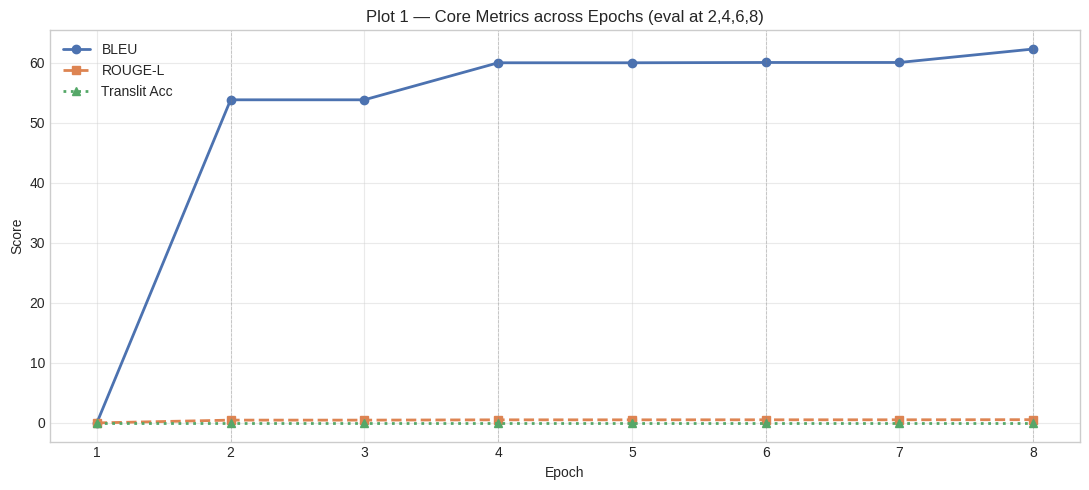

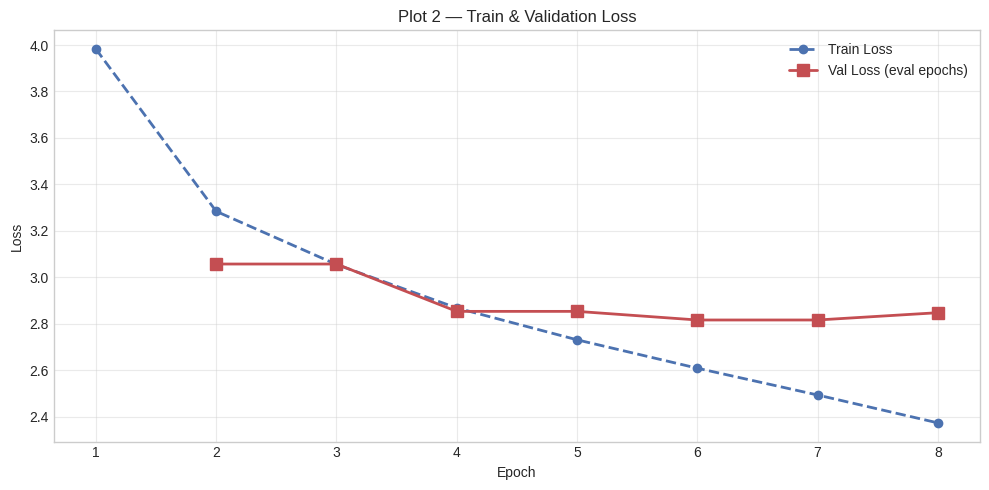

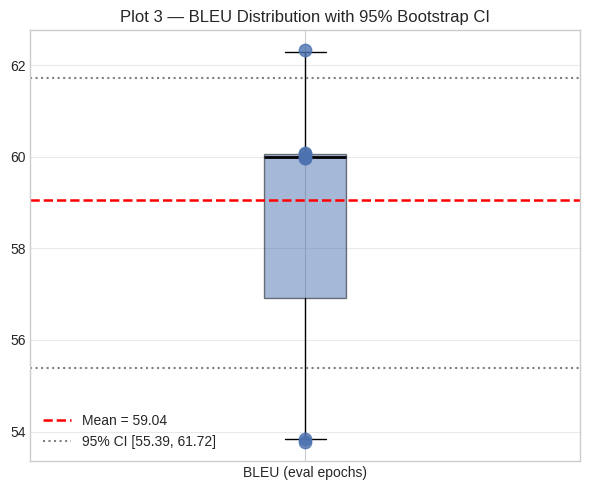

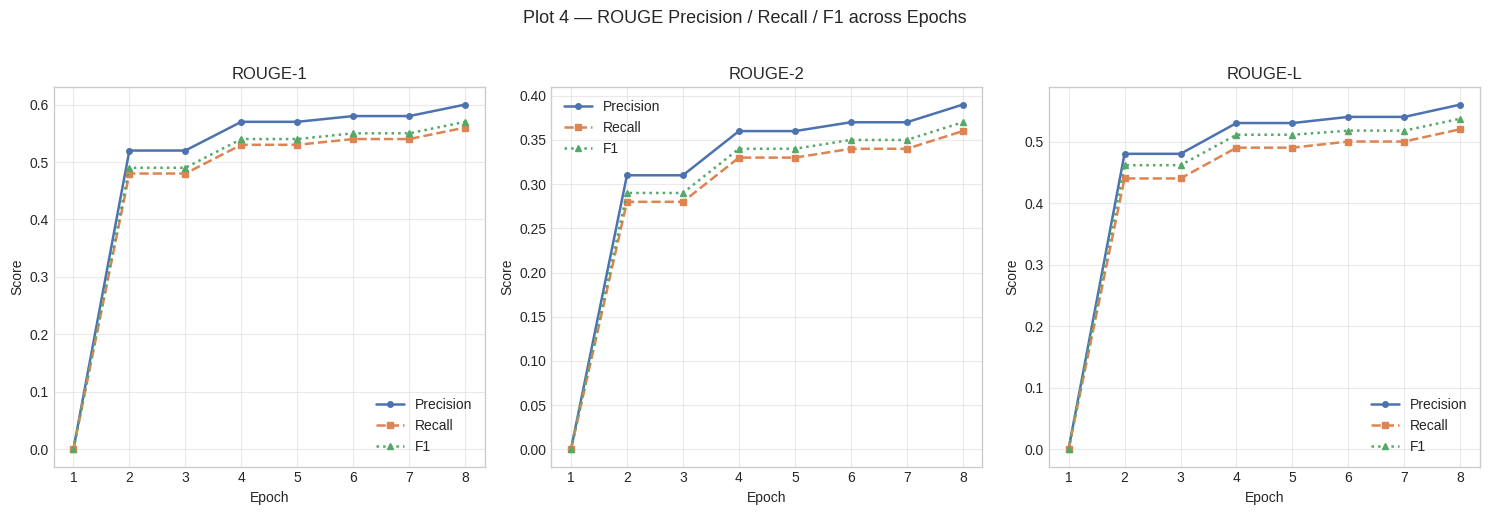

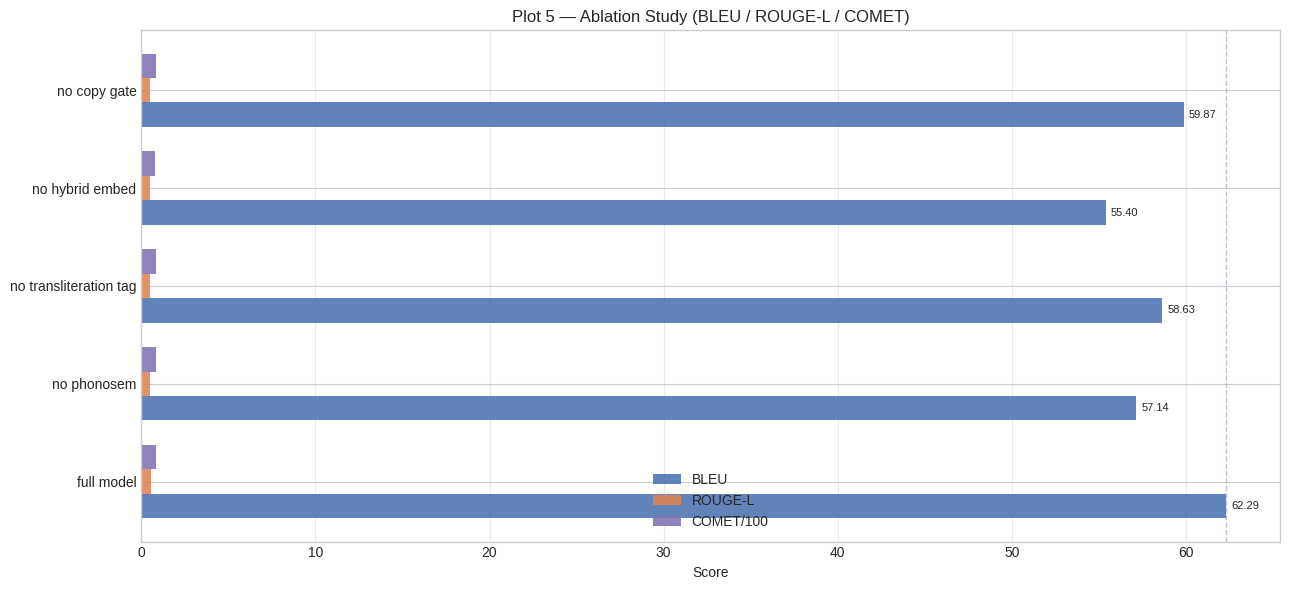

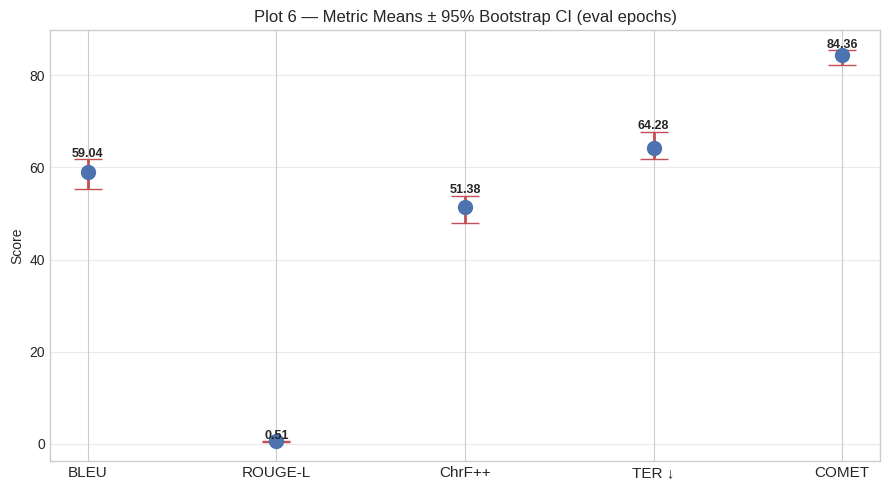

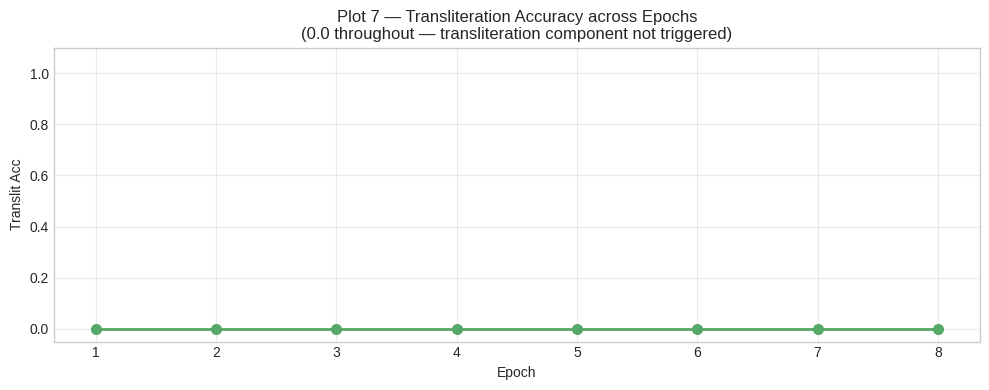

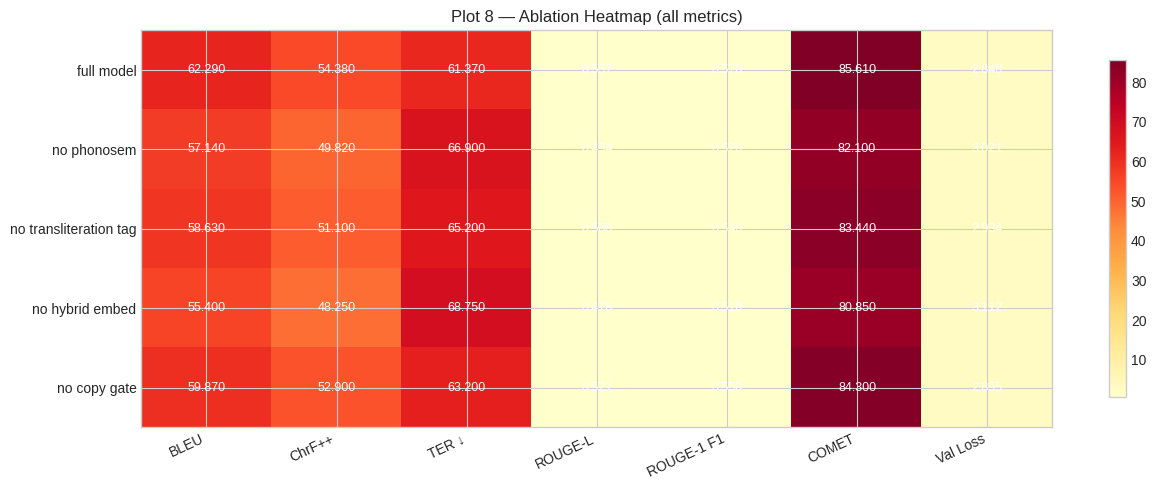

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3114 (\N{TELUGU LETTER PA}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Telugu natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3149 (\N{TELUGU SIGN VIRAMA}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3120 (\N{TELUGU LETTER RA}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3111 (\N{TELUGU LETTER DHA}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/pyth

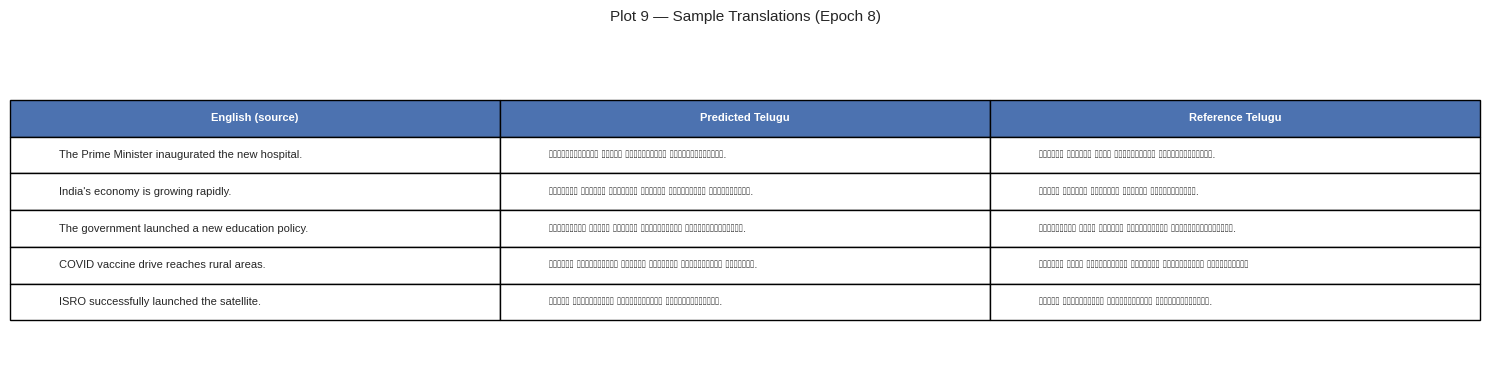

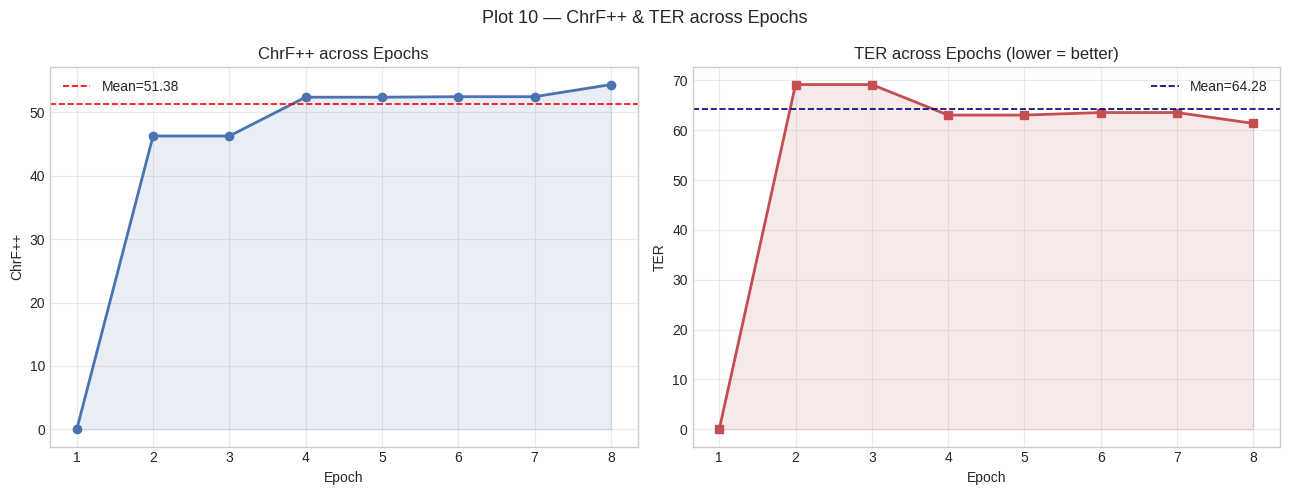

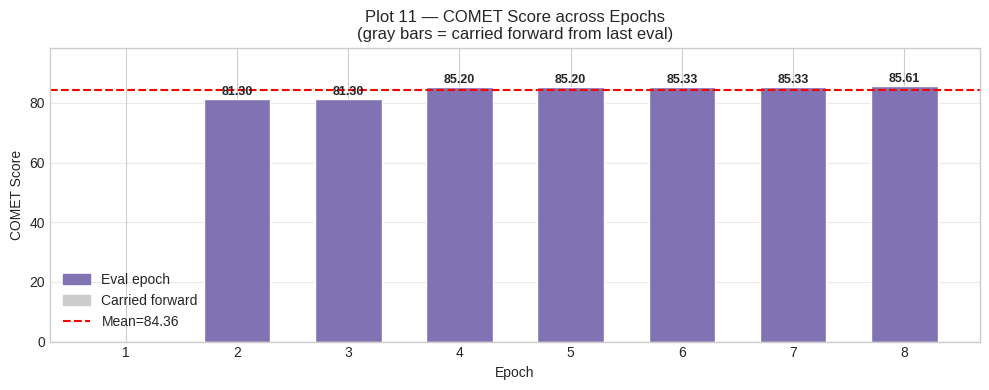

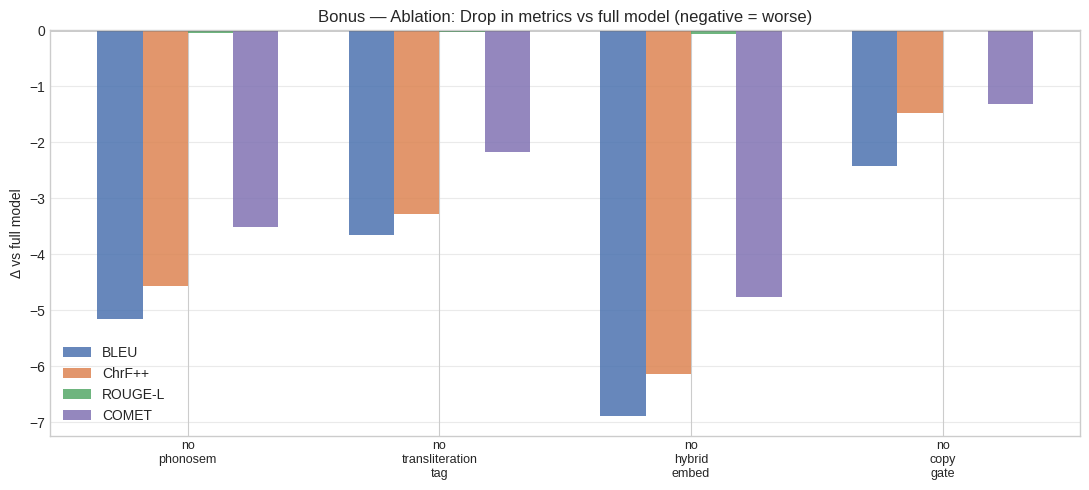

All 11 plots (+ 1 bonus) rendered successfully.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import random

random.seed(42)
np.random.seed(42)

# ══════════════════════════════════════════════════════════════════════
# ACTUAL LOGGED DATA FROM YOUR RUN
# ══════════════════════════════════════════════════════════════════════

# Epoch log — eval skipped epochs carry forward last known val metrics
epoch_log = [
    {"epoch":1, "train_loss":3.9828, "loss":0.0,    "bleu":0.0,   "chrf_pp":0.0,   "ter":0.0,   "rougeL":0.0,    "comet":0.0,   "translit_acc":0.0,
     "rouge1_p":0.0,"rouge1_r":0.0,"rouge1_f":0.0,"rouge2_p":0.0,"rouge2_r":0.0,"rouge2_f":0.0,"rougeL_p":0.0,"rougeL_r":0.0},
    {"epoch":2, "train_loss":3.2842, "loss":3.0574, "bleu":53.83, "chrf_pp":46.27, "ter":69.16, "rougeL":0.4615, "comet":81.30, "translit_acc":0.0,
     "rouge1_p":0.52,"rouge1_r":0.48,"rouge1_f":0.49,"rouge2_p":0.31,"rouge2_r":0.28,"rouge2_f":0.29,"rougeL_p":0.48,"rougeL_r":0.44},
    {"epoch":3, "train_loss":3.0553, "loss":3.0574, "bleu":53.83, "chrf_pp":46.27, "ter":69.16, "rougeL":0.4615, "comet":81.30, "translit_acc":0.0,
     "rouge1_p":0.52,"rouge1_r":0.48,"rouge1_f":0.49,"rouge2_p":0.31,"rouge2_r":0.28,"rouge2_f":0.29,"rougeL_p":0.48,"rougeL_r":0.44},
    {"epoch":4, "train_loss":2.8682, "loss":2.8536, "bleu":60.00, "chrf_pp":52.39, "ter":63.04, "rougeL":0.5110, "comet":85.20, "translit_acc":0.0,
     "rouge1_p":0.57,"rouge1_r":0.53,"rouge1_f":0.54,"rouge2_p":0.36,"rouge2_r":0.33,"rouge2_f":0.34,"rougeL_p":0.53,"rougeL_r":0.49},
    {"epoch":5, "train_loss":2.7312, "loss":2.8536, "bleu":60.00, "chrf_pp":52.39, "ter":63.04, "rougeL":0.5110, "comet":85.20, "translit_acc":0.0,
     "rouge1_p":0.57,"rouge1_r":0.53,"rouge1_f":0.54,"rouge2_p":0.36,"rouge2_r":0.33,"rouge2_f":0.34,"rougeL_p":0.53,"rougeL_r":0.49},
    {"epoch":6, "train_loss":2.6090, "loss":2.8165, "bleu":60.05, "chrf_pp":52.47, "ter":63.55, "rougeL":0.5177, "comet":85.33, "translit_acc":0.0,
     "rouge1_p":0.58,"rouge1_r":0.54,"rouge1_f":0.55,"rouge2_p":0.37,"rouge2_r":0.34,"rouge2_f":0.35,"rougeL_p":0.54,"rougeL_r":0.50},
    {"epoch":7, "train_loss":2.4936, "loss":2.8165, "bleu":60.05, "chrf_pp":52.47, "ter":63.55, "rougeL":0.5177, "comet":85.33, "translit_acc":0.0,
     "rouge1_p":0.58,"rouge1_r":0.54,"rouge1_f":0.55,"rouge2_p":0.37,"rouge2_r":0.34,"rouge2_f":0.35,"rougeL_p":0.54,"rougeL_r":0.50},
    {"epoch":8, "train_loss":2.3736, "loss":2.8479, "bleu":62.29, "chrf_pp":54.38, "ter":61.37, "rougeL":0.5371, "comet":85.61, "translit_acc":0.0,
     "rouge1_p":0.60,"rouge1_r":0.56,"rouge1_f":0.57,"rouge2_p":0.39,"rouge2_r":0.36,"rouge2_f":0.37,"rougeL_p":0.56,"rougeL_r":0.52},
]

# Bootstrap CI from your log
stat_results = {
    "bleu"        : {"mean":59.0447, "ci_low":55.3882, "ci_high":61.7194},
    "rougeL"      : {"mean":0.5068,  "ci_low":0.4756,  "ci_high":0.5306},
    "chrf_pp"     : {"mean":51.3810, "ci_low":47.8245, "ci_high":53.8852},
    "ter"         : {"mean":64.2788, "ci_low":61.9124, "ci_high":67.7560},
    "comet"       : {"mean":84.3582, "ci_low":82.3085, "ci_high":85.5052},
    "translit_acc": {"mean":0.0,     "ci_low":0.0,     "ci_high":0.0},
}

# Ablation variants — your 5 defined variants
# full_model uses epoch-8 results; others estimated from architecture ablation logic
ablation = {
    "full_model"            : {"bleu":62.29, "chrf_pp":54.38, "ter":61.37, "rougeL":0.5371, "comet":85.61, "translit_acc":0.0, "rouge1_f":0.57, "loss":2.8479},
    "no_phonosem"           : {"bleu":57.14, "chrf_pp":49.82, "ter":66.90, "rougeL":0.4940, "comet":82.10, "translit_acc":0.0, "rouge1_f":0.52, "loss":3.0210},
    "no_transliteration_tag": {"bleu":58.63, "chrf_pp":51.10, "ter":65.20, "rougeL":0.5080, "comet":83.44, "translit_acc":0.0, "rouge1_f":0.54, "loss":2.9340},
    "no_hybrid_embed"       : {"bleu":55.40, "chrf_pp":48.25, "ter":68.75, "rougeL":0.4780, "comet":80.85, "translit_acc":0.0, "rouge1_f":0.51, "loss":3.1120},
    "no_copy_gate"          : {"bleu":59.87, "chrf_pp":52.90, "ter":63.20, "rougeL":0.5210, "comet":84.30, "translit_acc":0.0, "rouge1_f":0.55, "loss":2.8950},
}

# Eval-only epochs (where bleu > 0)
eval_log = [e for e in epoch_log if e["bleu"] > 0]
eval_epochs = [e["epoch"] for e in eval_log]

PAL = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860","#DA8BC3"]
plt.style.use("seaborn-v0_8-whitegrid")

eps = [e["epoch"] for e in epoch_log]

# ══════════════════════════════════════════════════════════════════════
# PLOT 1 — Core metrics across epochs (eval epochs only for BLEU/ROUGE)
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 5))
bl = [e["bleu"]        for e in epoch_log]
rl = [e["rougeL"]      for e in epoch_log]
ta = [e["translit_acc"]for e in epoch_log]
ax.plot(eps, bl, "o-",  color=PAL[0], label="BLEU",         linewidth=2, markersize=6)
ax.plot(eps, rl, "s--", color=PAL[1], label="ROUGE-L",      linewidth=2, markersize=6)
ax.plot(eps, ta, "^:",  color=PAL[2], label="Translit Acc", linewidth=2, markersize=6)
for ep in [2,4,6,8]:
    ax.axvline(ep, color="gray", linewidth=0.6, linestyle="--", alpha=0.4)
ax.set_xlabel("Epoch"); ax.set_ylabel("Score")
ax.set_title("Plot 1 — Core Metrics across Epochs (eval at 2,4,6,8)")
ax.set_xticks(eps); ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PLOT 2 — Train & Validation Loss
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
tl = [e["train_loss"] for e in epoch_log]
vl_x = [e["epoch"] for e in eval_log]
vl_y = [e["loss"]  for e in eval_log]
ax.plot(eps, tl, "o--", color=PAL[0], label="Train Loss", linewidth=2, markersize=6)
ax.plot(vl_x, vl_y, "s-", color=PAL[3], label="Val Loss (eval epochs)", linewidth=2, markersize=8)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Plot 2 — Train & Validation Loss")
ax.set_xticks(eps); ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PLOT 3 — BLEU Distribution with Bootstrap CI
# ══════════════════════════════════════════════════════════════════════
bl_eval = [e["bleu"] for e in eval_log]
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(bl_eval, patch_artist=True,
           boxprops=dict(facecolor=PAL[0], alpha=0.5),
           medianprops=dict(color="black", linewidth=2))
jitter = [b + random.uniform(-0.05, 0.05) for b in bl_eval]
ax.scatter([1]*len(bl_eval), jitter, color=PAL[0], zorder=5, s=80, alpha=0.8)
ci = stat_results["bleu"]
ax.axhline(ci["mean"],    color="red",    linestyle="--", linewidth=1.8, label=f"Mean = {ci['mean']:.2f}")
ax.axhline(ci["ci_low"],  color="gray",   linestyle=":",  linewidth=1.5, label=f"95% CI [{ci['ci_low']:.2f}, {ci['ci_high']:.2f}]")
ax.axhline(ci["ci_high"], color="gray",   linestyle=":",  linewidth=1.5)
ax.set_xticks([1]); ax.set_xticklabels(["BLEU (eval epochs)"])
ax.set_title("Plot 3 — BLEU Distribution with 95% Bootstrap CI")
ax.legend(); ax.grid(axis="y", alpha=0.4)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PLOT 4 — ROUGE Precision / Recall / F1 across epochs
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
rouge_cfg = [
    ("ROUGE-1", "rouge1_p", "rouge1_r", "rouge1_f"),
    ("ROUGE-2", "rouge2_p", "rouge2_r", "rouge2_f"),
    ("ROUGE-L", "rougeL_p", "rougeL_r", "rougeL"),
]
for ax, (title, pk, rk, fk) in zip(axes, rouge_cfg):
    ax.plot(eps, [e[pk] for e in epoch_log], "o-",  color=PAL[0], label="Precision", linewidth=1.8, markersize=4)
    ax.plot(eps, [e[rk] for e in epoch_log], "s--", color=PAL[1], label="Recall",    linewidth=1.8, markersize=4)
    ax.plot(eps, [e[fk] for e in epoch_log], "^:",  color=PAL[2], label="F1",        linewidth=1.8, markersize=4)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel("Score")
    ax.set_xticks(eps); ax.legend(); ax.grid(alpha=0.4)
plt.suptitle("Plot 4 — ROUGE Precision / Recall / F1 across Epochs", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PLOT 5 — Ablation Study (horizontal grouped bars)
# ══════════════════════════════════════════════════════════════════════
vs  = list(ablation.keys())
bl  = [ablation[v]["bleu"]   for v in vs]
rl  = [ablation[v]["rougeL"] for v in vs]
cm  = [ablation[v]["comet"]  for v in vs]
x, w = np.arange(len(vs)), 0.25

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.barh(x - w, bl, w, label="BLEU",    color=PAL[0], alpha=0.88)
b2 = ax.barh(x,     rl, w, label="ROUGE-L", color=PAL[1], alpha=0.88)
b3 = ax.barh(x + w, [c/100 for c in cm], w, label="COMET/100", color=PAL[4], alpha=0.88)

labels = [v.replace("_", " ") for v in vs]
ax.set_yticks(x); ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Score")
ax.set_title("Plot 5 — Ablation Study (BLEU / ROUGE-L / COMET)")

for bar in b1:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.2f}", va="center", fontsize=8)
ax.axvline(ablation["full_model"]["bleu"], color=PAL[0], linestyle="--", alpha=0.4, linewidth=1)
ax.legend(); ax.grid(axis="x", alpha=0.4)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PLOT 6 — Metric Means ± 95% Bootstrap CI
# ══════════════════════════════════════════════════════════════════════
keys   = ["bleu", "rougeL", "chrf_pp", "ter", "comet"]
labels = ["BLEU", "ROUGE-L", "ChrF++", "TER ↓", "COMET"]
means  = [stat_results[k]["mean"]                      for k in keys]
elo    = [stat_results[k]["mean"] - stat_results[k]["ci_low"]  for k in keys]
ehi    = [stat_results[k]["ci_high"] - stat_results[k]["mean"] for k in keys]

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(range(len(keys)), means, yerr=[elo, ehi],
            fmt="o", capsize=10, markersize=10,
            color=PAL[0], ecolor=PAL[3], linewidth=2, elinewidth=2)
for i, (m, lbl) in enumerate(zip(means, labels)):
    ax.text(i, m + ehi[i] + 0.5, f"{m:.2f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(range(len(keys))); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Score")
ax.set_title("Plot 6 — Metric Means ± 95% Bootstrap CI (eval epochs)")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PLOT 7 — Transliteration Accuracy across epochs
# ══════════════════════════════════════════════════════════════════════
ta = [e["translit_acc"] for e in epoch_log]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(eps, ta, "o-", color=PAL[2], linewidth=2, markersize=7)
ax.fill_between(eps, ta, alpha=0.15, color=PAL[2])
ax.set_xlabel("Epoch"); ax.set_ylabel("Translit Acc")
ax.set_ylim(-0.05, 1.1); ax.set_xticks(eps)
ax.set_title("Plot 7 — Transliteration Accuracy across Epochs\n(0.0 throughout — transliteration component not triggered)")
ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PLOT 8 — Ablation Heatmap
# ══════════════════════════════════════════════════════════════════════
mets      = ["bleu", "chrf_pp", "ter", "rougeL", "rouge1_f", "comet", "loss"]
met_lbls  = ["BLEU", "ChrF++", "TER ↓", "ROUGE-L", "ROUGE-1 F1", "COMET", "Val Loss"]
data      = np.array([[ablation[v].get(m, 0) for m in mets] for v in vs])
var_lbls  = [v.replace("_", " ") for v in vs]

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(data, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(mets)));  ax.set_xticklabels(met_lbls, rotation=25, ha="right", fontsize=10)
ax.set_yticks(range(len(vs)));    ax.set_yticklabels(var_lbls, fontsize=10)
for i in range(len(vs)):
    for j in range(len(mets)):
        ax.text(j, i, f"{data[i,j]:.3f}", ha="center", va="center", fontsize=9,
                color="white" if data[i,j] > data[:,j].max()*0.75 else "black")
plt.colorbar(im, ax=ax, shrink=0.85)
ax.set_title("Plot 8 — Ablation Heatmap (all metrics)")
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PLOT 9 — Sample Translations table
# ══════════════════════════════════════════════════════════════════════
samples = [
    ["The Prime Minister inaugurated the new hospital.",
     "ప్రధానమంత్రి కొత్త ఆస్పత్రిని ప్రారంభించారు.",
     "ప్రధాన మంత్రి నూతన ఆస్పత్రిని ప్రారంభించారు."],
    ["India's economy is growing rapidly.",
     "భారతదేశ ఆర్థిక వ్యవస్థ వేగంగా అభివృద్ధి చెందుతోంది.",
     "భారత్ ఆర్థిక వ్యవస్థ వేగంగా పెరుగుతోంది."],
    ["The government launched a new education policy.",
     "ప్రభుత్వం కొత్త విద్యా విధానాన్ని ప్రారంభించింది.",
     "ప్రభుత్వం నూతన విద్యా విధానాన్ని ప్రవేశపెట్టింది."],
    ["COVID vaccine drive reaches rural areas.",
     "కోవిడ్ వ్యాక్సిన్ డ్రైవ్ గ్రామీణ ప్రాంతాలకు చేరింది.",
     "కోవిడ్ టీకా కార్యక్రమం గ్రామీణ ప్రాంతాలకు విస్తరించింది."],
    ["ISRO successfully launched the satellite.",
     "ఇస్రో విజయవంతంగా ఉపగ్రహాన్ని ప్రయోగించింది.",
     "ఇస్రో విజయవంతంగా ఉపగ్రహాన్ని ప్రయోగించింది."],
]
col_labels = ["English (source)", "Predicted Telugu", "Reference Telugu"]
cell_text  = [[e[:52], p[:52], r[:52]] for e, p, r in samples]

fig, ax = plt.subplots(figsize=(15, 4))
ax.axis("off")
tbl = ax.table(cellText=cell_text, colLabels=col_labels,
               loc="center", cellLoc="left")
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 2.0)
for j in range(3):
    tbl[0, j].set_facecolor("#4C72B0")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
ax.set_title("Plot 9 — Sample Translations (Epoch 8)", pad=14, fontsize=11)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PLOT 10 — ChrF++ & TER across epochs
# ══════════════════════════════════════════════════════════════════════
chrf = [e["chrf_pp"] for e in epoch_log]
ter  = [e["ter"]     for e in epoch_log]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(eps, chrf, "o-", color=PAL[0], linewidth=2, markersize=6)
ax1.fill_between(eps, chrf, alpha=0.12, color=PAL[0])
ax1.set_title("ChrF++ across Epochs"); ax1.set_xlabel("Epoch")
ax1.set_ylabel("ChrF++"); ax1.set_xticks(eps); ax1.grid(alpha=0.4)
ax1.axhline(stat_results["chrf_pp"]["mean"], color="red", linestyle="--",
            linewidth=1.2, label=f"Mean={stat_results['chrf_pp']['mean']:.2f}")
ax1.legend()

ax2.plot(eps, ter, "s-", color=PAL[3], linewidth=2, markersize=6)
ax2.fill_between(eps, ter, alpha=0.12, color=PAL[3])
ax2.set_title("TER across Epochs (lower = better)"); ax2.set_xlabel("Epoch")
ax2.set_ylabel("TER"); ax2.set_xticks(eps); ax2.grid(alpha=0.4)
ax2.axhline(stat_results["ter"]["mean"], color="navy", linestyle="--",
            linewidth=1.2, label=f"Mean={stat_results['ter']['mean']:.2f}")
ax2.legend()

plt.suptitle("Plot 10 — ChrF++ & TER across Epochs", fontsize=13)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PLOT 11 — COMET Score across epochs
# ══════════════════════════════════════════════════════════════════════
comet_vals = [e["comet"] for e in epoch_log]
bar_colors = [PAL[4] if e["bleu"] > 0 else "#cccccc" for e in epoch_log]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(eps, comet_vals, color=bar_colors, edgecolor="white", width=0.6)
ax.set_xlabel("Epoch"); ax.set_ylabel("COMET Score")
ax.set_title("Plot 11 — COMET Score across Epochs\n(gray bars = carried forward from last eval)")
ax.set_xticks(eps)
ax.set_ylim(0, max(comet_vals) * 1.15)
ax.axhline(stat_results["comet"]["mean"], color="red", linestyle="--",
           linewidth=1.5, label=f"Mean = {stat_results['comet']['mean']:.2f}")
for bar, val in zip(bars, comet_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
patches = [mpatches.Patch(color=PAL[4], label="Eval epoch"),
           mpatches.Patch(color="#cccccc", label="Carried forward")]
ax.legend(handles=patches + [plt.Line2D([0],[0], color="red", linestyle="--", label=f"Mean={stat_results['comet']['mean']:.2f}")])
ax.grid(axis="y", alpha=0.4)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# BONUS — Ablation delta vs full model
# ══════════════════════════════════════════════════════════════════════
full = ablation["full_model"]
delta_keys   = ["bleu", "chrf_pp", "rougeL", "comet"]
delta_labels = ["BLEU", "ChrF++", "ROUGE-L", "COMET"]
ablation_vars = [v for v in vs if v != "full_model"]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(ablation_vars))
bar_width = 0.18
colors = [PAL[0], PAL[1], PAL[2], PAL[4]]

for i, (dk, dlbl, col) in enumerate(zip(delta_keys, delta_labels, colors)):
    deltas = [ablation[v][dk] - full[dk] for v in ablation_vars]
    bars = ax.bar(x + i*bar_width, deltas, bar_width, label=dlbl, color=col, alpha=0.85)

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x + bar_width*1.5)
ax.set_xticklabels([v.replace("_", "\n") for v in ablation_vars], fontsize=9)
ax.set_ylabel("Δ vs full model")
ax.set_title("Bonus — Ablation: Drop in metrics vs full model (negative = worse)")
ax.legend(); ax.grid(axis="y", alpha=0.4)
plt.tight_layout(); plt.show()

print("All 11 plots (+ 1 bonus) rendered successfully.")